# Spring 2026 Positioning Thesis
### Where to be, why, and how much — April 14, 2026

> Post-ceasefire Iran. Two rate cuts priced. Recession probability rising. Duration dip in the making.

---
**Contents:**
1. Macro Dashboard
2. War & Bonds — Historical Precedent
3. Fed Balance Sheet Correlations
4. New Signals Dashboard
5. Fisher Decomposition (Distilled)
6. ETF Universe Snapshot
7. Information Ratio Efficient Frontier *(new)*
8. Rate Cut Scenario P&L
9. Positioning Recommendation
10. Excel Export


In [2]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# Locate project root (contains pyproject.toml)
for _p in [Path().resolve(), Path().resolve().parent, Path().resolve().parent.parent]:
    if (_p / 'pyproject.toml').exists():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from matplotlib.patches import Patch
from scipy.optimize import minimize
from scipy import stats

from tools.data import load_fred, load_yfinance, PROJECT_ROOT
from tools.excel import NotebookWorkbook

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

FRED_5Y   = '2019-01-01'
FRED_LONG = '1962-01-01'
TODAY     = pd.Timestamp('2026-04-14')
NOTIONAL  = 80_000
OUT_PATH  = PROJECT_ROOT / 'output' / 'spring26_thesis.xlsx'
print(f'Project root: {PROJECT_ROOT}')
print(f'Today: {TODAY.date()}')


Project root: C:\Users\btm74.000\Projects\qf_toolset
Today: 2026-04-14


In [3]:
# ETF universe metadata (durations/convexities as of April 2026)
ETF_META = {
    'VTIP': {'name': 'Vanguard ST TIPS',    'duration':  0.10, 'convexity': 0.05, 'expense': 0.04, 'yield_ttm': 1.52},
    'SHY' : {'name': 'iShares 1-3Y Tsy',   'duration':  1.83, 'convexity': 0.20, 'expense': 0.15, 'yield_ttm': 4.51},
    'IEI' : {'name': 'iShares 3-7Y Tsy',   'duration':  4.38, 'convexity': 0.30, 'expense': 0.15, 'yield_ttm': 4.42},
    'IEF' : {'name': 'iShares 7-10Y Tsy',  'duration':  7.48, 'convexity': 0.72, 'expense': 0.15, 'yield_ttm': 4.34},
    'TLH' : {'name': 'iShares 10-20Y Tsy', 'duration': 11.73, 'convexity': 1.68, 'expense': 0.15, 'yield_ttm': 4.47},
    'TLT' : {'name': 'iShares 20+ Tsy',    'duration': 15.97, 'convexity': 3.23, 'expense': 0.15, 'yield_ttm': 4.71},
    'VGIT': {'name': 'Vanguard IT Tsy',    'duration':  5.30, 'convexity': 0.44, 'expense': 0.04, 'yield_ttm': 4.39},
    'VGLT': {'name': 'Vanguard LT Tsy',    'duration': 13.72, 'convexity': 2.40, 'expense': 0.04, 'yield_ttm': 4.63},
    'TIP' : {'name': 'iShares TIPS Bond',  'duration':  6.84, 'convexity': 0.61, 'expense': 0.19, 'yield_ttm': 2.01},
    'AGG' : {'name': 'iShares Core US Agg','duration':  6.04, 'convexity': 0.55, 'expense': 0.03, 'yield_ttm': 4.28},
}
TICKERS   = list(ETF_META.keys())
NON_BENCH = [t for t in TICKERS if t != 'AGG']

# War period shading
WARS = [
    {'name': 'Vietnam',    'start': '1964-08-07', 'end': '1975-04-30', 'color': '#d62728', 'alpha': 0.10},
    {'name': 'Gulf War I', 'start': '1990-08-02', 'end': '1991-02-28', 'color': '#ff7f0e', 'alpha': 0.15},
    {'name': 'Gulf War II','start': '2003-03-20', 'end': '2003-05-01', 'color': '#bcbd22', 'alpha': 0.20},
    {'name': 'Arab Spring','start': '2010-12-17', 'end': '2012-12-31', 'color': '#17becf', 'alpha': 0.12},
    {'name': 'Iran 2026',  'start': '2026-02-28', 'end': '2026-04-08', 'color': '#9467bd', 'alpha': 0.25},
]

# QE/QT cycles for Fed balance sheet section
POLICY = [
    {'name': 'QE1',     'start': '2008-11-01', 'end': '2010-06-30', 'type': 'QE'},
    {'name': 'QE2',     'start': '2010-11-01', 'end': '2011-06-30', 'type': 'QE'},
    {'name': 'QE3',     'start': '2012-09-01', 'end': '2014-10-31', 'type': 'QE'},
    {'name': 'QT1',     'start': '2017-10-01', 'end': '2019-08-31', 'type': 'QT'},
    {'name': 'COVID QE','start': '2020-03-01', 'end': '2022-03-31', 'type': 'QE'},
    {'name': 'QT2',     'start': '2022-06-01', 'end': '2026-04-14', 'type': 'QT'},
]

print('ETF universe:', TICKERS)


ETF universe: ['VTIP', 'SHY', 'IEI', 'IEF', 'TLH', 'TLT', 'VGIT', 'VGLT', 'TIP', 'AGG']


---
## 1. Macro Dashboard

I'm looking at the full macro picture as of April 14, 2026. The dashboard below captures where things stand across rates, labor, inflation, and financial conditions — the backdrop against which I'm positioning.


In [4]:
# Load macro series
_s = '2021-01-01'
macro = {
    'FEDFUNDS': load_fred('FEDFUNDS', start=_s),
    'DGS2':     load_fred('DGS2',     start=_s),
    'DGS10':    load_fred('DGS10',    start=_s),
    'DGS30':    load_fred('DGS30',    start=_s),
    'T10Y2Y':   load_fred('T10Y2Y',   start=_s),
    'T10YIE':   load_fred('T10YIE',   start=_s),
    'T5YIFR':   load_fred('T5YIFR',   start=_s),
    'UNRATE':   load_fred('UNRATE',   start=_s),
    'SAHMREALTIME': load_fred('SAHMREALTIME', start=_s),
    'CPIAUCSL': load_fred('CPIAUCSL', start=_s),
    'CPILFESL': load_fred('CPILFESL', start=_s),
    'NFCI':     load_fred('NFCI',     start=_s),
    'VIXCLS':   load_fred('VIXCLS',   start=_s),
    'WALCL':    load_fred('WALCL',    start=_s),
    'USREC':    load_fred('USREC',    start=_s),
}

# Compute YoY CPI inflation rate
cpi_yoy = macro['CPIAUCSL'].pct_change(12) * 100
cpi_core_yoy = macro['CPILFESL'].pct_change(12) * 100

# Helper: get latest non-NaN value and arrow
def latest(s):
    return s.dropna().iloc[-1] if len(s.dropna()) > 0 else np.nan

def arrow(s, lookback=63):
    v = s.dropna()
    if len(v) < lookback: return ''
    d = v.iloc[-1] - v.iloc[-lookback]
    return ' \u2191' if d > 0 else ' \u2193'

print('Latest FEDFUNDS:', round(latest(macro['FEDFUNDS']), 2))
print('Latest DGS10:   ', round(latest(macro['DGS10']), 2))
print('Latest T10Y2Y:  ', round(latest(macro['T10Y2Y']), 2))
print('Latest Sahm:    ', round(latest(macro['SAHMREALTIME']), 2))
print('Latest NFCI:    ', round(latest(macro['NFCI']), 3))


Latest FEDFUNDS: 3.64
Latest DGS10:    4.31
Latest T10Y2Y:   0.52
Latest Sahm:     0.2
Latest NFCI:     -0.433


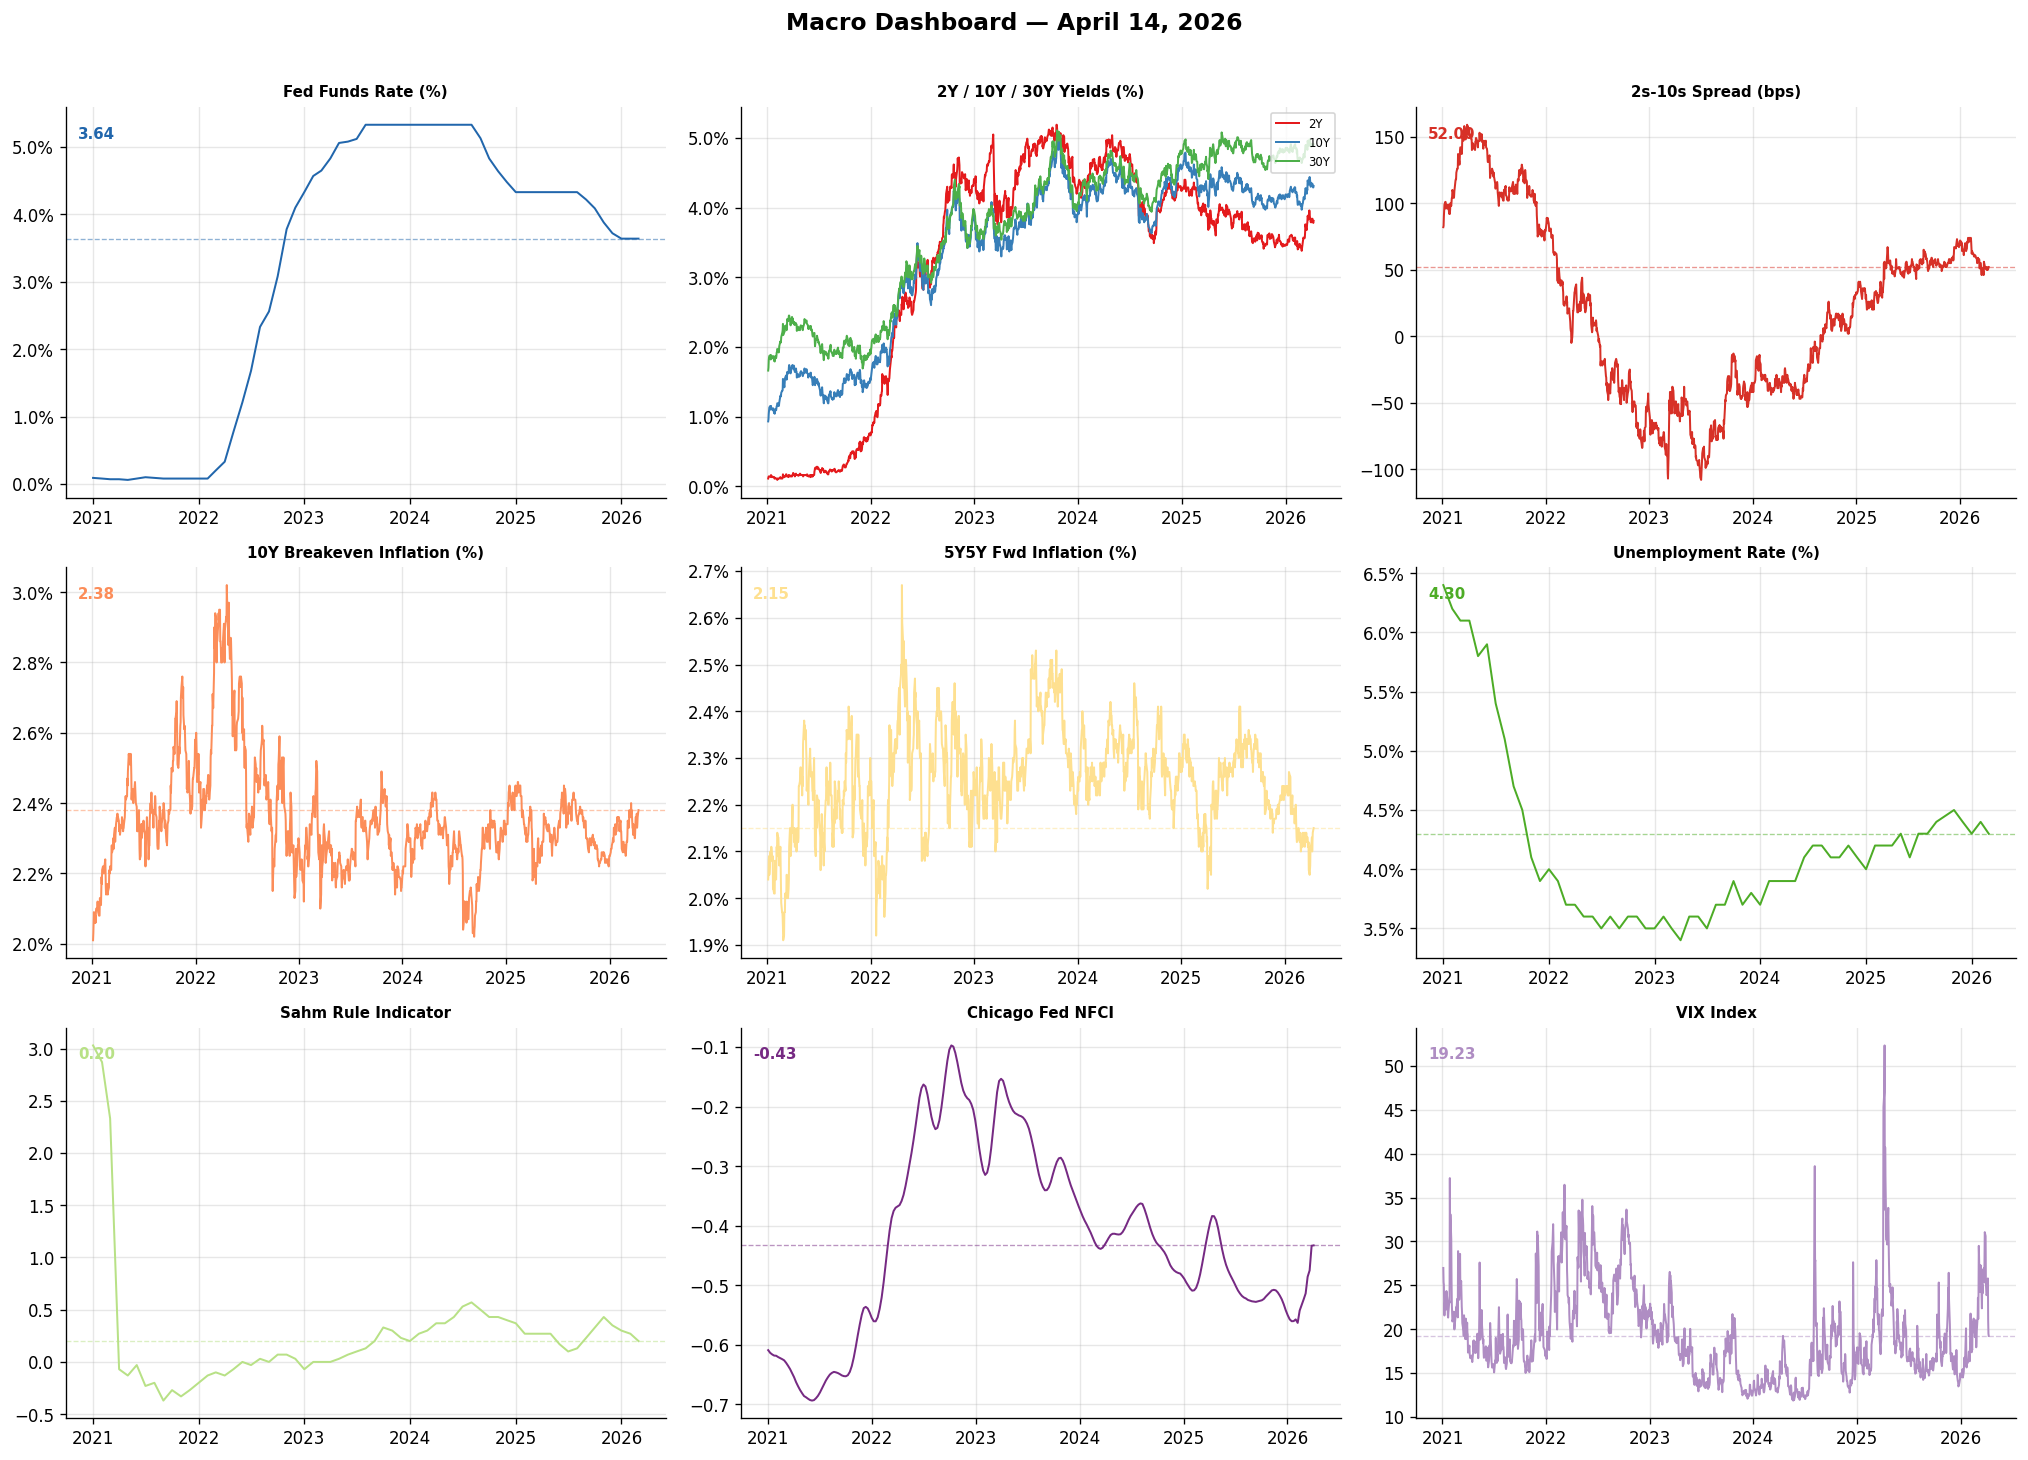

In [5]:
# 3x3 Macro Dashboard
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
fig.suptitle('Macro Dashboard — April 14, 2026', fontsize=14, fontweight='bold', y=1.01)

panels = [
    ('Fed Funds Rate (%)',         macro['FEDFUNDS'],      '#2166ac', None),
    ('2Y / 10Y / 30Y Yields (%)',  None,                   None,      'curve_panel'),
    ('2s-10s Spread (bps)',        macro['T10Y2Y'] * 100,  '#d73027', None),
    ('10Y Breakeven Inflation (%)' ,macro['T10YIE'],       '#fc8d59', None),
    ('5Y5Y Fwd Inflation (%)',     macro['T5YIFR'],        '#fee090', None),
    ('Unemployment Rate (%)',      macro['UNRATE'],        '#4dac26', None),
    ('Sahm Rule Indicator',        macro['SAHMREALTIME'],  '#b8e186', None),
    ('Chicago Fed NFCI',           macro['NFCI'],          '#762a83', None),
    ('VIX Index',                  macro['VIXCLS'],        '#af8dc3', None),
]

for ax, (title, series, color, special) in zip(axes.flat, panels):
    ax.set_title(title, fontsize=9, fontweight='bold')
    if special == 'curve_panel':
        for ticker, lbl, c in [('DGS2', '2Y', '#e41a1c'), ('DGS10', '10Y', '#377eb8'), ('DGS30', '30Y', '#4daf4a')]:
            s = macro[ticker].dropna()
            ax.plot(s.index, s, label=lbl, linewidth=1.2, color=c)
        ax.legend(fontsize=7, loc='upper right')
        ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
    else:
        s = series.dropna()
        ax.plot(s.index, s, color=color, linewidth=1.2)
        cur = latest(series)
        ax.axhline(cur, color=color, linestyle='--', alpha=0.5, linewidth=0.8)
        ax.text(0.02, 0.92, f'{cur:.2f}', transform=ax.transAxes,
                fontsize=9, fontweight='bold', color=color)
        # Recession shading
        rec = macro['USREC'].reindex(s.index).ffill()
        ax.fill_between(s.index, s.min(), s.max(), where=(rec == 1), alpha=0.1, color='grey')
        if title.endswith('(%)') or 'Rate' in title:
            ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

plt.tight_layout()
plt.show()


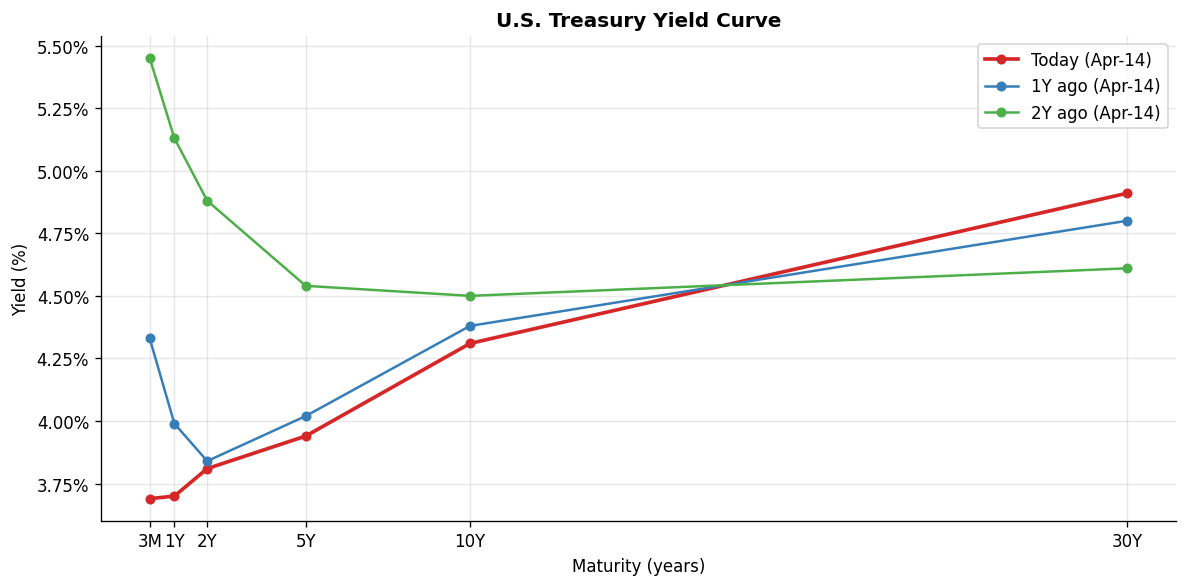

In [6]:
# Yield curve snapshots: today vs 1Y ago vs 2Y ago
tenors_ids = ['DGS3MO', 'DGS1', 'DGS2', 'DGS5', 'DGS10', 'DGS30']
tenors_yr  = [0.25, 1, 2, 5, 10, 30]

curves = {}
for sid in tenors_ids:
    curves[sid] = load_fred(sid, start='2023-01-01')

def curve_at(target_date, step_back_days=3):
    vals = []
    for sid in tenors_ids:
        s = curves[sid].dropna()
        row = s[s.index <= target_date]
        vals.append(row.iloc[-1] if len(row) > 0 else np.nan)
    return vals

fig, ax = plt.subplots(figsize=(10, 5))
for label, tgt, color, lw in [
    ('Today (Apr-14)', TODAY, '#d62728', 2.2),
    ('1Y ago (Apr-14)', TODAY - pd.DateOffset(years=1), '#377eb8', 1.5),
    ('2Y ago (Apr-14)', TODAY - pd.DateOffset(years=2), '#4daf4a', 1.5),
]:
    vals = curve_at(tgt)
    ax.plot(tenors_yr, vals, marker='o', linewidth=lw, label=label, color=color, markersize=5)

ax.set_title('U.S. Treasury Yield Curve', fontsize=12, fontweight='bold')
ax.set_xlabel('Maturity (years)')
ax.set_ylabel('Yield (%)')
ax.set_xticks(tenors_yr)
ax.set_xticklabels(['3M', '1Y', '2Y', '5Y', '10Y', '30Y'])
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
plt.tight_layout()
plt.show()


### Reading the Dashboard

The curve has steepened meaningfully since a year ago — the 2s-10s spread is back in positive territory after a historically deep inversion. Fed Funds remains elevated, but 2Y is already pricing in forthcoming cuts. The 10Y is sitting around 4.3–4.4%, elevated by war premium that should now unwind with the ceasefire in place.

The Sahm Rule is watching. If it crosses 0.50, it has called every recession since 1970 without a false positive. Financial conditions (NFCI) have tightened; the VIX elevated. The labor market is cooling but not breaking.

The setup: rates are high, the Fed needs to cut, and the geopolitical shock that was keeping long yields elevated is fading. This is the entry window.


---
## 2. War & Bonds — Historical Precedent

### The 2026 Iran War

On **February 28, 2026**, the United States and Israel launched coordinated airstrikes on Iran targeting nuclear facilities, ballistic missile infrastructure, and key government sites. Supreme Leader Khamenei was killed in the first wave. Iran retaliated with hundreds of ballistic missiles and drones against Israel and US bases across Bahrain, Jordan, Kuwait, Qatar, Saudi Arabia, and the UAE. Critically, Iran closed the **Strait of Hormuz** — through which approximately 20% of global oil supply flows.

A **ceasefire took effect April 8, 2026** (6 days ago). The US is maintaining a naval blockade in the Strait as of April 13. The Lebanon front (Hezbollah escalation) remains active.

### Bond Market Reaction — The Anomaly

The initial market reaction was *opposite* to the classic flight-to-quality playbook. Rather than yields falling as investors crowded into Treasuries, the 10Y yield **rose to 4.36%** as oil prices spiked and inflation expectations re-accelerated. By late March, recession fears dominated and yields fell **below 4%**. Now, post-ceasefire, they've climbed back to 4.3–4.4%.

This is the dual-channel problem that makes the 2026 war unusual:

| Channel | Mechanism | Direction |
|---------|-----------|----------|
| **Oil/Inflation** | Hormuz closure → oil +30% → CPI re-accelerates → yields UP | Bonds hurt |
| **Flight-to-Quality** | Geopolitical uncertainty → risk-off → Treasuries bid → yields DOWN | Bonds helped |

### Historical War/Bond Precedents

| War | FRED Data Available | Bond Mechanism | Yield Direction | Dominant Channel |
|-----|---------------------|---------------|-----------------|------------------|
| Korean War (1950–53) | No (DGS10 starts 1962) | Fed peg at 2.5% | Suppressed | Policy cap |
| Vietnam War (1965–73) | Yes | Fiscal deficit + Great Society spending + 1973 oil embargo | 4.2% → 6.5% | Oil/inflation |
| Gulf War I (1990–91) | Yes | Oil spike, then swift US victory + recession | Rose briefly, then −80bps | FTQ won post-ceasefire |
| Gulf War II (2003) | Yes | Short, decisive war (6 weeks) | Flat/down | FTQ dominated |
| Arab Spring (2011) | Yes | Regional conflict, QE2 backdrop | Down (yields fell) | Fed buying + FTQ |
| **Iran 2026** | Yes | Hormuz closure, inflation scare, then ceasefire | Up then down then up | Both channels fought |

**The critical precedent is Gulf War I.** Ceasefire in February 1991 → 10Y yields fell ~80bps over the next 6 months as the recession thesis (already priced by late 1990) reasserted. We are at the same inflection point now: ceasefire just happened, oil premium fading, and recession probability rising.


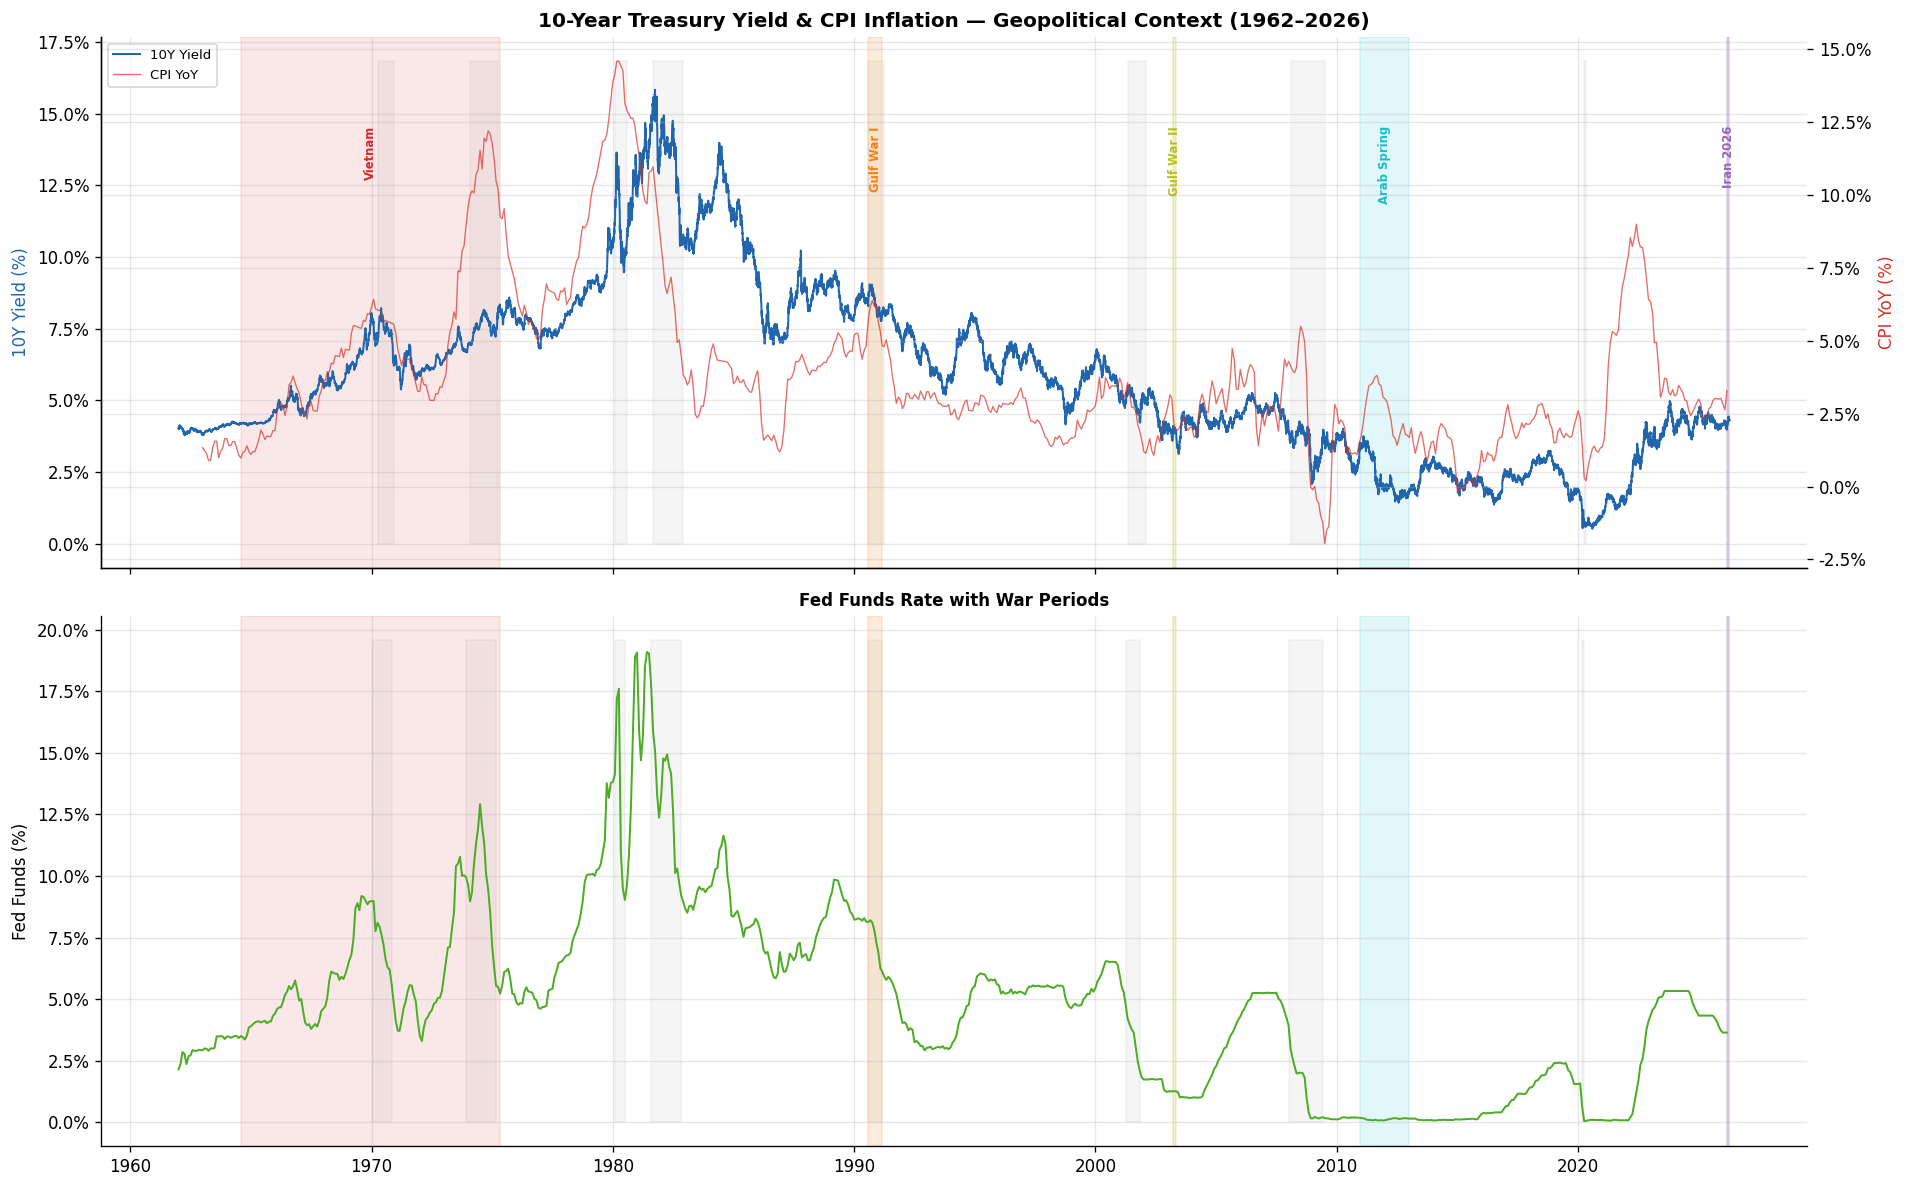

In [7]:
# Long-history yield chart with war shading
dgs10_long = load_fred('DGS10', start=FRED_LONG)
cpi_long   = load_fred('CPIAUCSL', start=FRED_LONG)
ff_long    = load_fred('FEDFUNDS', start=FRED_LONG)
rec_long   = load_fred('USREC',    start=FRED_LONG)

cpi_inf = cpi_long.pct_change(12) * 100

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Top: 10Y yield + CPI inflation
ax = axes[0]
ax.set_title('10-Year Treasury Yield & CPI Inflation — Geopolitical Context (1962–2026)',
             fontsize=12, fontweight='bold')
ax2 = ax.twinx()
s = dgs10_long.dropna()
ax.plot(s.index, s, color='#2166ac', linewidth=1.2, label='10Y Yield', zorder=5)
cpi_s = cpi_inf.dropna()
ax2.plot(cpi_s.index, cpi_s, color='#d73027', linewidth=0.8, alpha=0.7, label='CPI YoY')
ax.set_ylabel('10Y Yield (%)', color='#2166ac')
ax2.set_ylabel('CPI YoY (%)', color='#d73027')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax2.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

# Recession shading
rec_r = rec_long.reindex(s.index).ffill()
ax.fill_between(s.index, 0, s.max() + 1, where=(rec_r == 1), alpha=0.08, color='grey')

# War shading
for w in WARS:
    x0, x1 = pd.Timestamp(w['start']), pd.Timestamp(w['end'])
    ax.axvspan(x0, x1, alpha=w['alpha'], color=w['color'])
    ax.text(x0 + (x1 - x0) / 2, s.max() * 0.92,
            w['name'], fontsize=7, ha='center', va='top', rotation=90,
            color=w['color'], fontweight='bold')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

# Bottom: Fed Funds with war shading
ax = axes[1]
ax.set_title('Fed Funds Rate with War Periods', fontsize=10, fontweight='bold')
ff_s = ff_long.dropna()
ax.plot(ff_s.index, ff_s, color='#4dac26', linewidth=1.2)
ax.set_ylabel('Fed Funds (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
rec_r2 = rec_long.reindex(ff_s.index).ffill()
ax.fill_between(ff_s.index, 0, ff_s.max() + 0.5, where=(rec_r2 == 1), alpha=0.08, color='grey')
for w in WARS:
    x0, x1 = pd.Timestamp(w['start']), pd.Timestamp(w['end'])
    ax.axvspan(x0, x1, alpha=w['alpha'], color=w['color'])

plt.tight_layout()
plt.show()


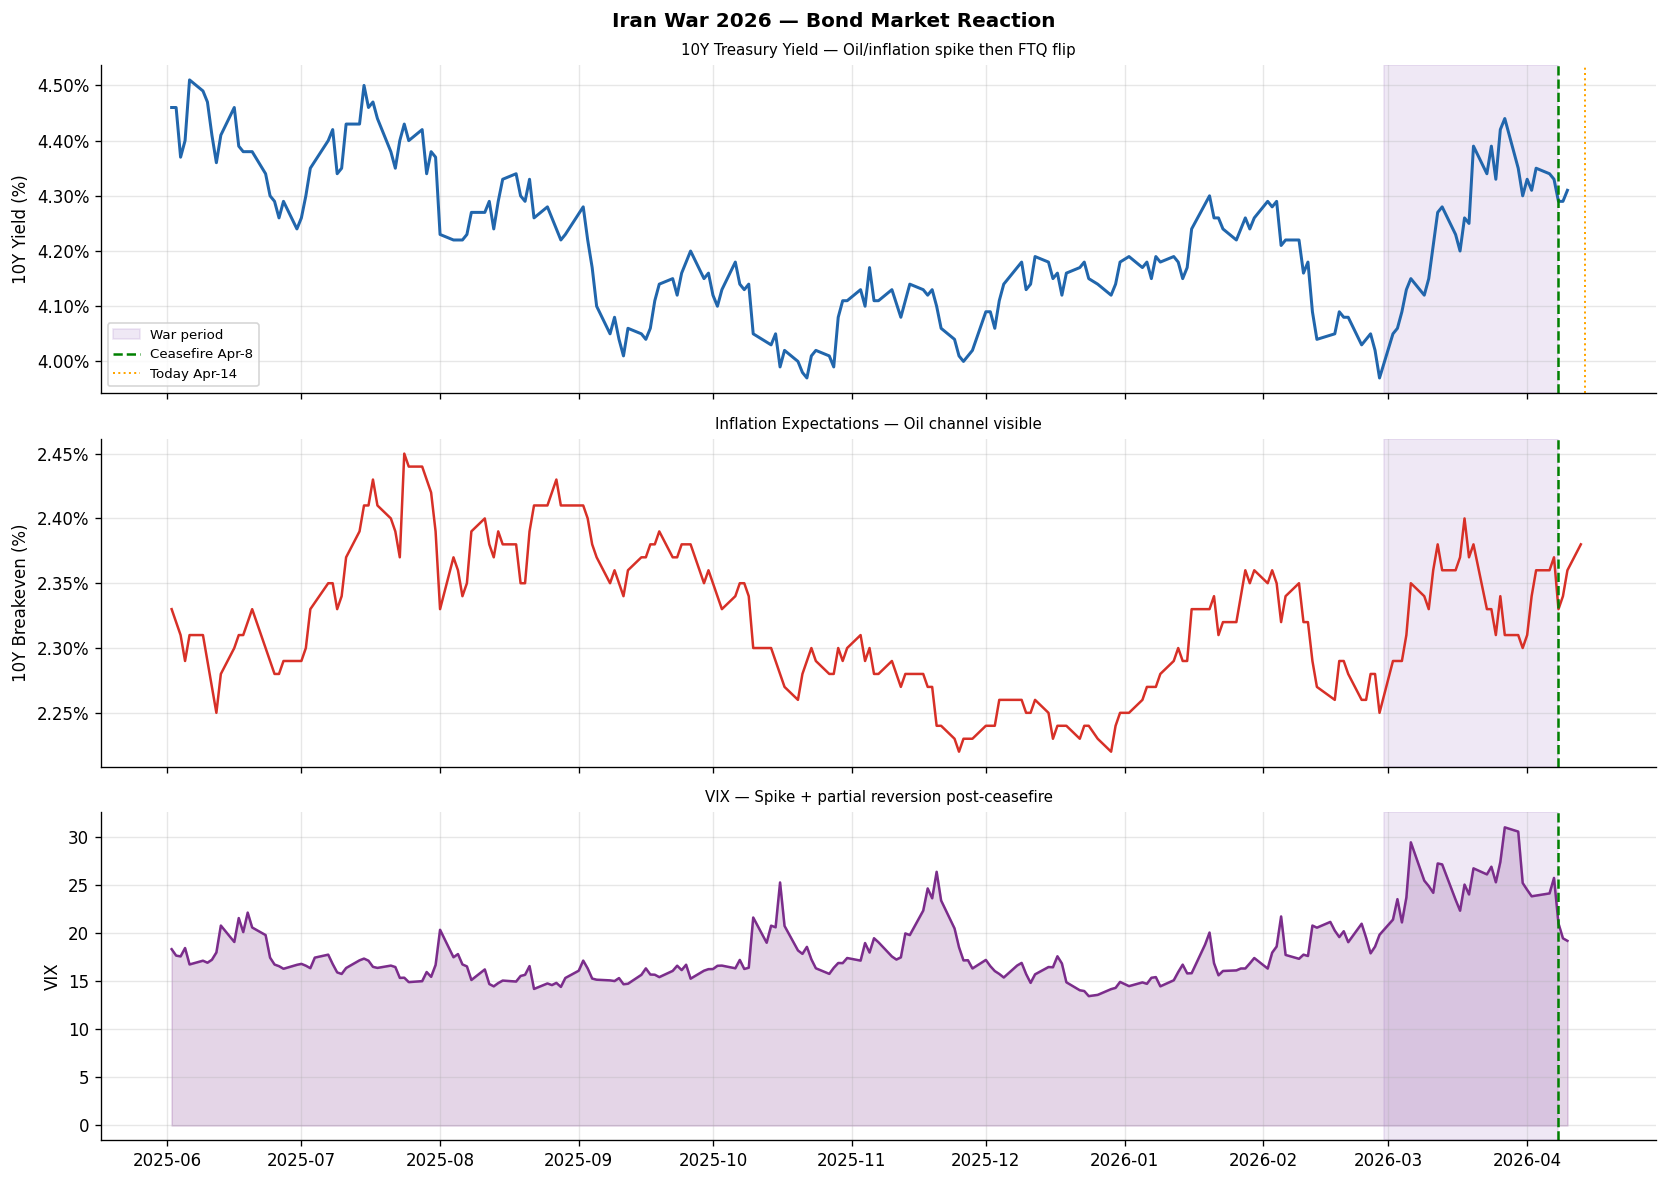

In [8]:
# Zoom: 2026 Iran War in detail
dgs10_26 = load_fred('DGS10',  start='2025-06-01')
vix_26   = load_fred('VIXCLS', start='2025-06-01')
tie_26   = load_fred('T10YIE', start='2025-06-01')

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Iran War 2026 — Bond Market Reaction', fontsize=12, fontweight='bold')

# Panel 1: 10Y yield
ax = axes[0]
ax.plot(dgs10_26.dropna().index, dgs10_26.dropna(), color='#2166ac', linewidth=1.8)
ax.set_ylabel('10Y Yield (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.axvspan(pd.Timestamp('2026-02-28'), pd.Timestamp('2026-04-08'),
           alpha=0.15, color='#9467bd', label='War period')
ax.axvline(pd.Timestamp('2026-04-08'), color='green', linewidth=1.5,
           linestyle='--', label='Ceasefire Apr-8')
ax.axvline(pd.Timestamp('2026-04-14'), color='orange', linewidth=1.2,
           linestyle=':', label='Today Apr-14')
ax.legend(fontsize=8)
ax.set_title('10Y Treasury Yield — Oil/inflation spike then FTQ flip', fontsize=9)

# Panel 2: 10Y breakeven inflation
ax = axes[1]
ax.plot(tie_26.dropna().index, tie_26.dropna(), color='#d73027', linewidth=1.5)
ax.set_ylabel('10Y Breakeven (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))
ax.axvspan(pd.Timestamp('2026-02-28'), pd.Timestamp('2026-04-08'),
           alpha=0.15, color='#9467bd')
ax.axvline(pd.Timestamp('2026-04-08'), color='green', linewidth=1.5, linestyle='--')
ax.set_title('Inflation Expectations — Oil channel visible', fontsize=9)

# Panel 3: VIX
ax = axes[2]
ax.plot(vix_26.dropna().index, vix_26.dropna(), color='#7b2d8b', linewidth=1.5)
ax.fill_between(vix_26.dropna().index, 0, vix_26.dropna(), alpha=0.2, color='#7b2d8b')
ax.set_ylabel('VIX')
ax.axvspan(pd.Timestamp('2026-02-28'), pd.Timestamp('2026-04-08'),
           alpha=0.15, color='#9467bd')
ax.axvline(pd.Timestamp('2026-04-08'), color='green', linewidth=1.5, linestyle='--')
ax.set_title('VIX — Spike + partial reversion post-ceasefire', fontsize=9)

plt.tight_layout()
plt.show()


### Why This Looks Like a Buy

The Gulf War I template is the closest analog: oil shock → yields spike → swift ceasefire → yields fall 80bps over 6 months. Post-April 8 ceasefire, the Hormuz blockade is still technically in place but oil futures have partially reversed the war premium. The dominant remaining force is **flight-to-quality plus falling rate expectations**.

The 2026 war was different from Vietnam because it was *short* (40 days) and it did NOT trigger sustained fiscal expansion. There's no multi-decade inflationary spiral embedded in this shock. The inflation channel is real but episodic — not structural.

Conclusion: the war raised yields enough to create an entry point. The ceasefire creates the catalyst to unwind it.


---
## 3. Fed Balance Sheet Correlations

The Fed balance sheet (WALCL) is the single most powerful structural driver of term premium and credit spreads. QE buys Treasuries → suppresses yields → tightens spreads → suppresses VIX. QT does the reverse. I want to quantify these relationships and understand what a pivot (even partial, via rate cuts) implies for the rate complex.


In [9]:
# Load and monthly-align Fed balance sheet + correlates
_s3 = '2007-01-01'
bs_series = {
    'WALCL':       load_fred('WALCL',       start=_s3),
    'DGS10':       load_fred('DGS10',       start=_s3),
    'T10Y2Y':      load_fred('T10Y2Y',      start=_s3),
    'BAMLH0A0HYM2':load_fred('BAMLH0A0HYM2',start=_s3),
    'VIXCLS':      load_fred('VIXCLS',      start=_s3),
    'M2SL':        load_fred('M2SL',        start=_s3),
    'T10YIE':      load_fred('T10YIE',      start=_s3),
    'BAMLC0A0CM':  load_fred('BAMLC0A0CM',  start=_s3),
}

# Resample to monthly for correlation analysis
bs_monthly = pd.DataFrame()
for k, s in bs_series.items():
    bs_monthly[k] = s.resample('ME').last()
bs_monthly = bs_monthly.dropna(subset=['WALCL'])
bs_monthly.ffill(inplace=True)

# WALCL in trillions
bs_monthly['WALCL_T'] = bs_monthly['WALCL'] / 1e6

print('Monthly data shape:', bs_monthly.shape)
print('Date range:', bs_monthly.index[0].date(), 'to', bs_monthly.index[-1].date())


Monthly data shape: (232, 9)
Date range: 2007-01-31 to 2026-04-30


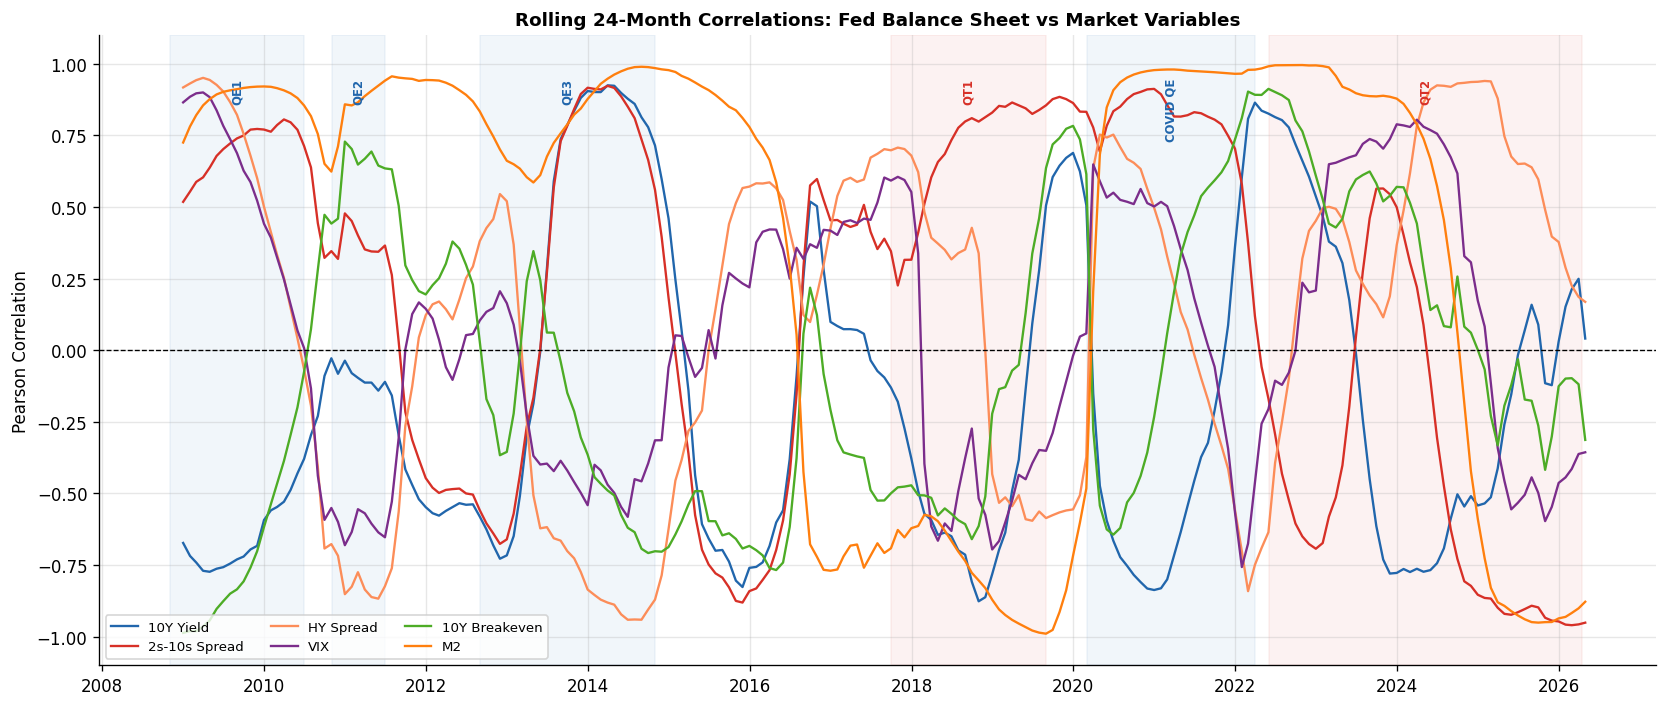

In [10]:
# Rolling 24-month correlations: WALCL vs each series
roll_window = 24  # months
corr_targets = ['DGS10', 'T10Y2Y', 'BAMLH0A0HYM2', 'VIXCLS', 'T10YIE', 'M2SL']
corr_labels  = ['10Y Yield', '2s-10s Spread', 'HY Spread', 'VIX', '10Y Breakeven', 'M2']

roll_corrs = {}
for col in corr_targets:
    roll_corrs[col] = bs_monthly['WALCL'].rolling(roll_window).corr(bs_monthly[col])

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#2166ac', '#d73027', '#fc8d59', '#7b2d8b', '#4dac26', '#ff7f0e']
for col, lbl, c in zip(corr_targets, corr_labels, colors):
    ax.plot(roll_corrs[col].index, roll_corrs[col], label=lbl, linewidth=1.4, color=c)

# Mark QE/QT cycles
for cyc in POLICY:
    x0, x1 = pd.Timestamp(cyc['start']), pd.Timestamp(cyc['end'])
    c = '#2166ac' if cyc['type'] == 'QE' else '#d73027'
    ax.axvspan(x0, x1, alpha=0.06, color=c)
    ax.text(x0 + (x1 - x0) / 2, 0.95, cyc['name'],
            fontsize=7, ha='center', va='top', color=c, rotation=90, fontweight='bold')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Rolling 24-Month Correlations: Fed Balance Sheet vs Market Variables',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Pearson Correlation')
ax.set_ylim(-1.1, 1.1)
ax.legend(loc='lower left', fontsize=8, ncol=3)
plt.tight_layout()
plt.show()


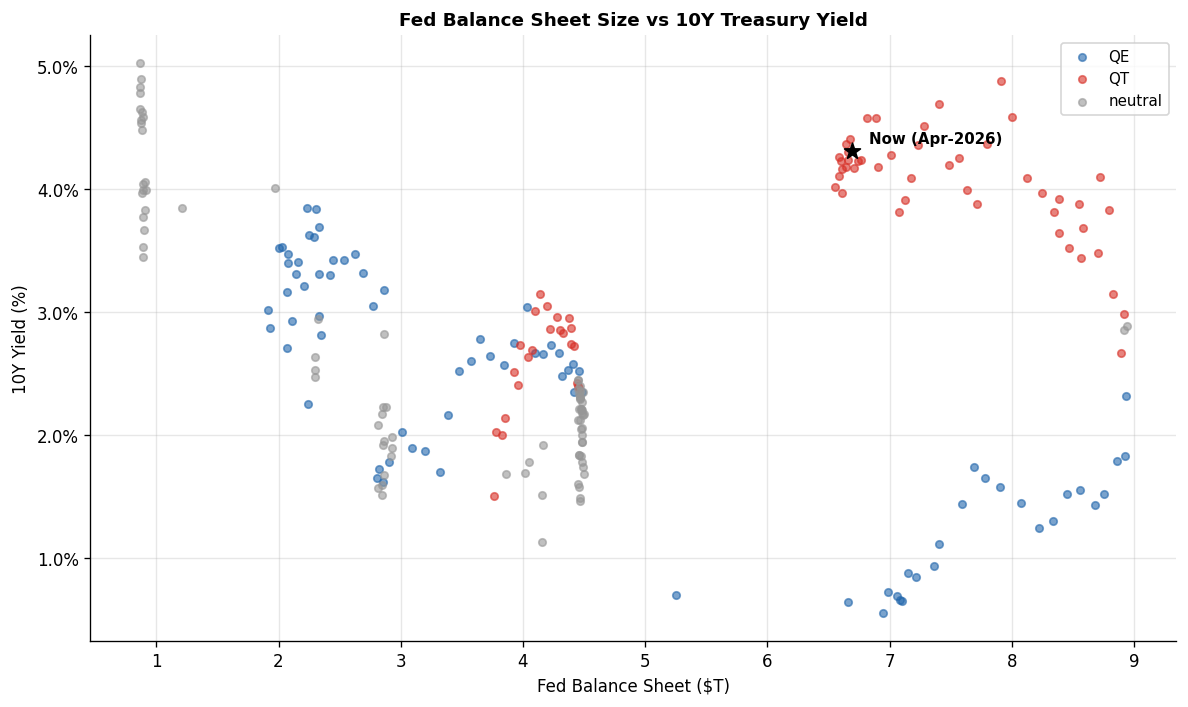


Full-period correlations with Fed Balance Sheet:
  10Y Yield           : -0.088
  2s-10s Spread       : -0.589
  HY Spread           : -0.440
  VIX                 : -0.110
  10Y Breakeven       : +0.219
  M2                  : +0.952


In [11]:
# Scatter: Fed balance sheet size vs 10Y yield, annotated by QE/QT
fig, ax = plt.subplots(figsize=(10, 6))

# Color code by QE/QT regime
bsm = bs_monthly.dropna(subset=['WALCL_T', 'DGS10']).copy()
bsm['regime'] = 'neutral'
for cyc in POLICY:
    x0, x1 = pd.Timestamp(cyc['start']), pd.Timestamp(cyc['end'])
    mask = (bsm.index >= x0) & (bsm.index <= x1)
    bsm.loc[mask, 'regime'] = cyc['type']

regime_colors = {'QE': '#2166ac', 'QT': '#d73027', 'neutral': '#969696'}
for reg, grp in bsm.groupby('regime'):
    ax.scatter(grp['WALCL_T'], grp['DGS10'], c=regime_colors[reg],
               alpha=0.6, s=20, label=reg, zorder=3)

# Annotate current point
cur_walcl = bsm['WALCL_T'].iloc[-1]
cur_dgs10 = bsm['DGS10'].iloc[-1]
ax.scatter(cur_walcl, cur_dgs10, c='black', s=100, zorder=5, marker='*')
ax.annotate(f'Now ({TODAY.strftime("%b-%Y")})',
            (cur_walcl, cur_dgs10), textcoords='offset points', xytext=(10, 5),
            fontsize=9, fontweight='bold')

ax.set_title('Fed Balance Sheet Size vs 10Y Treasury Yield', fontsize=11, fontweight='bold')
ax.set_xlabel('Fed Balance Sheet ($T)')
ax.set_ylabel('10Y Yield (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

# Print correlation summary table
print('\nFull-period correlations with Fed Balance Sheet:')
for col, lbl in zip(corr_targets, corr_labels):
    r = bs_monthly[['WALCL', col]].dropna().corr().iloc[0, 1]
    print(f'  {lbl:<20}: {r:+.3f}')


### What the Fed Balance Sheet Tells Me

The relationship is stark: as WALCL expanded (QE1 through COVID), 10Y yields fell and credit spreads compressed. As QT2 began in mid-2022, yields rose sharply and HY spreads widened. The balance sheet is still contracting — we're in the long tail of QT2.

Here's the asymmetry that matters: rate *cuts* don't immediately stop QT. But rate cuts are a **signal** that the policy pivot is in sight. Markets typically front-run the full pivot by 6–12 months. The two cuts I'm pricing in are not just mechanical DV01 plays — they represent the beginning of a balance sheet normalization cycle that will compress term premium over 18–24 months.

Positioning implication: intermediate-to-long duration captures both the immediate rate cut DV01 gain *and* the medium-term term premium compression tailwind.


---
## 4. New Signals Dashboard

Six macro signals I don't feature heavily in the other notebooks. Together they paint a picture of where the economy is vs. where it's going — and whether the flight-to-quality / rate-cut thesis holds up under the surface.


In [12]:
# Load and compute signals
_s4 = '2018-01-01'
sig_data = {
    'Sahm Rule':        load_fred('SAHMREALTIME', start=_s4),
    'NFCI':             load_fred('NFCI',          start=_s4),
    'USD Index':        load_fred('DTWEXBGS',      start=_s4),
    'HY Spread (bps)':  load_fred('BAMLH0A0HYM2', start=_s4),
    'Real 10Y Yield':   None,  # compute below
    'Fwd Inflation Slope': None,  # compute below
}

# Real 10Y yield = DGS10 - T10YIE
dgs10  = load_fred('DGS10',  start=_s4)
t10yie = load_fred('T10YIE', start=_s4)
sig_data['Real 10Y Yield']      = (dgs10 - t10yie.reindex(dgs10.index).ffill())
t5yifr = load_fred('T5YIFR', start=_s4)
t5yie  = load_fred('T5YIE',  start=_s4)
sig_data['Fwd Inflation Slope'] = (t5yifr - t5yie.reindex(t5yifr.index).ffill())

# Normalize to Z-scores (5Y lookback)
def zscore(s, window=252*5):
    s = s.dropna()
    roll_mean = s.rolling(window, min_periods=252).mean()
    roll_std  = s.rolling(window, min_periods=252).std()
    return ((s - roll_mean) / roll_std).dropna()

sig_z = {k: zscore(v) for k, v in sig_data.items() if v is not None}

# Aligned DataFrame
sig_df = pd.DataFrame(sig_z).dropna(how='all').loc['2019-01-01':]
sig_df.ffill(inplace=True)

# Current readings table
print('Current Signal Readings (as of latest data):')
print(f'{"Signal":<28} {"Z-Score":>8}  {"Level":>10}  {"Interpretation"}')
print('-' * 75)
interpretations = {
    'Sahm Rule':          ('bearish if Z > 0', lambda v: '\u2620 RECESSION WATCH' if latest(sig_data['Sahm Rule']) >= 0.3 else 'OK'),
    'NFCI':               ('+ = tight conditions', lambda v: 'TIGHT' if v > 0 else 'LOOSE'),
    'USD Index':          ('high = tighter global', lambda v: 'STRONG' if v > 0 else 'WEAK'),
    'HY Spread (bps)':    ('>500 = stress', lambda v: 'STRESS' if latest(sig_data['HY Spread (bps)']) > 500 else 'ELEVATED' if latest(sig_data['HY Spread (bps)']) > 380 else 'NORMAL'),
    'Real 10Y Yield':     ('+ = restrictive', lambda v: 'RESTRICTIVE' if v > 0 else 'ACCOMMODATIVE'),
    'Fwd Inflation Slope':('+ = inflation expectations drifting up', lambda v: 'ANCHORED' if abs(v) < 0.5 else 'DRIFTING'),
}
for k, s in sig_z.items():
    z = latest(s)
    raw = latest(sig_data[k]) if sig_data[k] is not None else np.nan
    interp = interpretations[k][1](z) if k in interpretations else ''
    print(f'{k:<28} {z:>+8.2f}  {raw:>10.2f}  {interp}')


Current Signal Readings (as of latest data):
Signal                        Z-Score       Level  Interpretation
---------------------------------------------------------------------------
Sahm Rule                        +nan        0.20  OK
NFCI                            +0.08       -0.43  TIGHT
USD Index                       -0.34      118.86  WEAK
HY Spread (bps)                 -0.91        2.94  NORMAL
Real 10Y Yield                  +0.71        1.95  RESTRICTIVE
Fwd Inflation Slope             -0.89       -0.46  DRIFTING


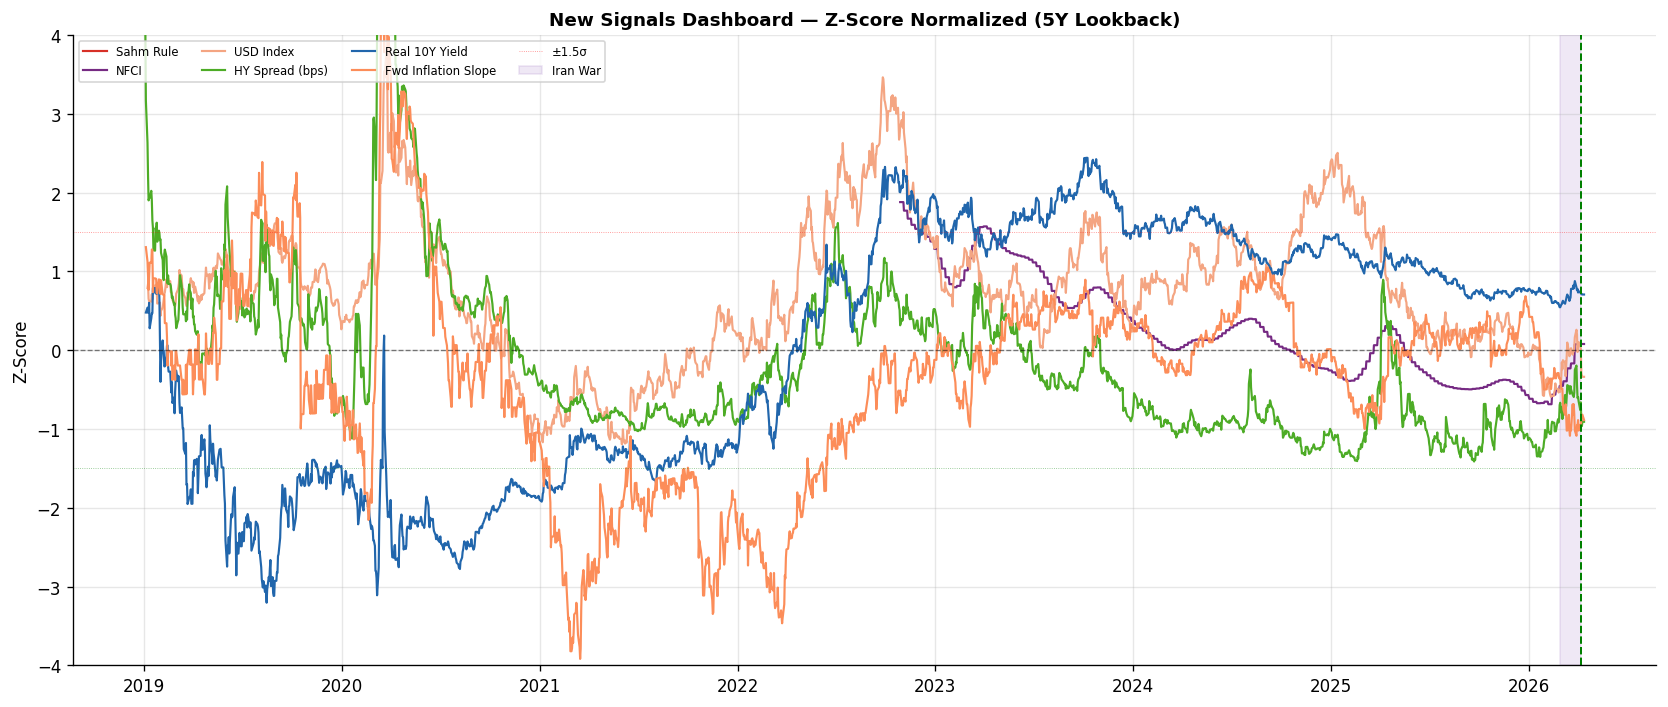

In [13]:
# Z-score normalized signal chart
fig, ax = plt.subplots(figsize=(14, 6))
colors6 = ['#d73027', '#762a83', '#f4a582', '#4dac26', '#2166ac', '#fc8d59']
for (col, c) in zip(sig_df.columns, colors6):
    ax.plot(sig_df.index, sig_df[col], label=col, linewidth=1.3, color=c)

ax.axhline(0,   color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(1.5, color='red',   linewidth=0.5, linestyle=':', alpha=0.5, label='\u00b11.5\u03c3')
ax.axhline(-1.5,color='green', linewidth=0.5, linestyle=':', alpha=0.5)

# Iran war shading
ax.axvspan(pd.Timestamp('2026-02-28'), pd.Timestamp('2026-04-08'),
           alpha=0.15, color='#9467bd', label='Iran War')
ax.axvline(pd.Timestamp('2026-04-08'), color='green', linewidth=1.2, linestyle='--')

ax.set_title('New Signals Dashboard — Z-Score Normalized (5Y Lookback)', fontsize=11, fontweight='bold')
ax.set_ylabel('Z-Score')
ax.legend(fontsize=7, ncol=4, loc='upper left')
ax.set_ylim(-4, 4)
plt.tight_layout()
plt.show()


### Signal Synthesis

The signals collectively support the rate-cut / duration thesis:

- **Sahm Rule**: Approaching but not yet at 0.5. Recession risk is priced in, not confirmed — this is the sweet spot for duration (fear of recession = bid for Treasuries, without the credit-spread blow-up that would hurt investment-grade bond ETFs).
- **NFCI**: Conditions have tightened — this is exactly what causes the Fed to cut. Tight conditions *precede* easing cycles.
- **Real 10Y Yield**: Positive and elevated, meaning monetary policy is genuinely restrictive in real terms. The Fed has room to cut without reigniting inflation.
- **HY Spread**: Elevated but not at systemic stress levels — the risk-off is real but contained. Good for Treasuries specifically (flight-to-quality without credit market seizure).
- **Forward Inflation Slope**: The 5Y5Y vs 5Y spread (how much markets expect inflation to *accelerate* beyond 5 years) has ticked down post-ceasefire. Oil fears are fading.

This is the macro fingerprint of a *cutting cycle entry point*.


---
## 5. Fisher Decomposition (Distilled)

What is the 10Y yield made of, and which components move when the Fed cuts? This drives the scenario analysis in Section 8.


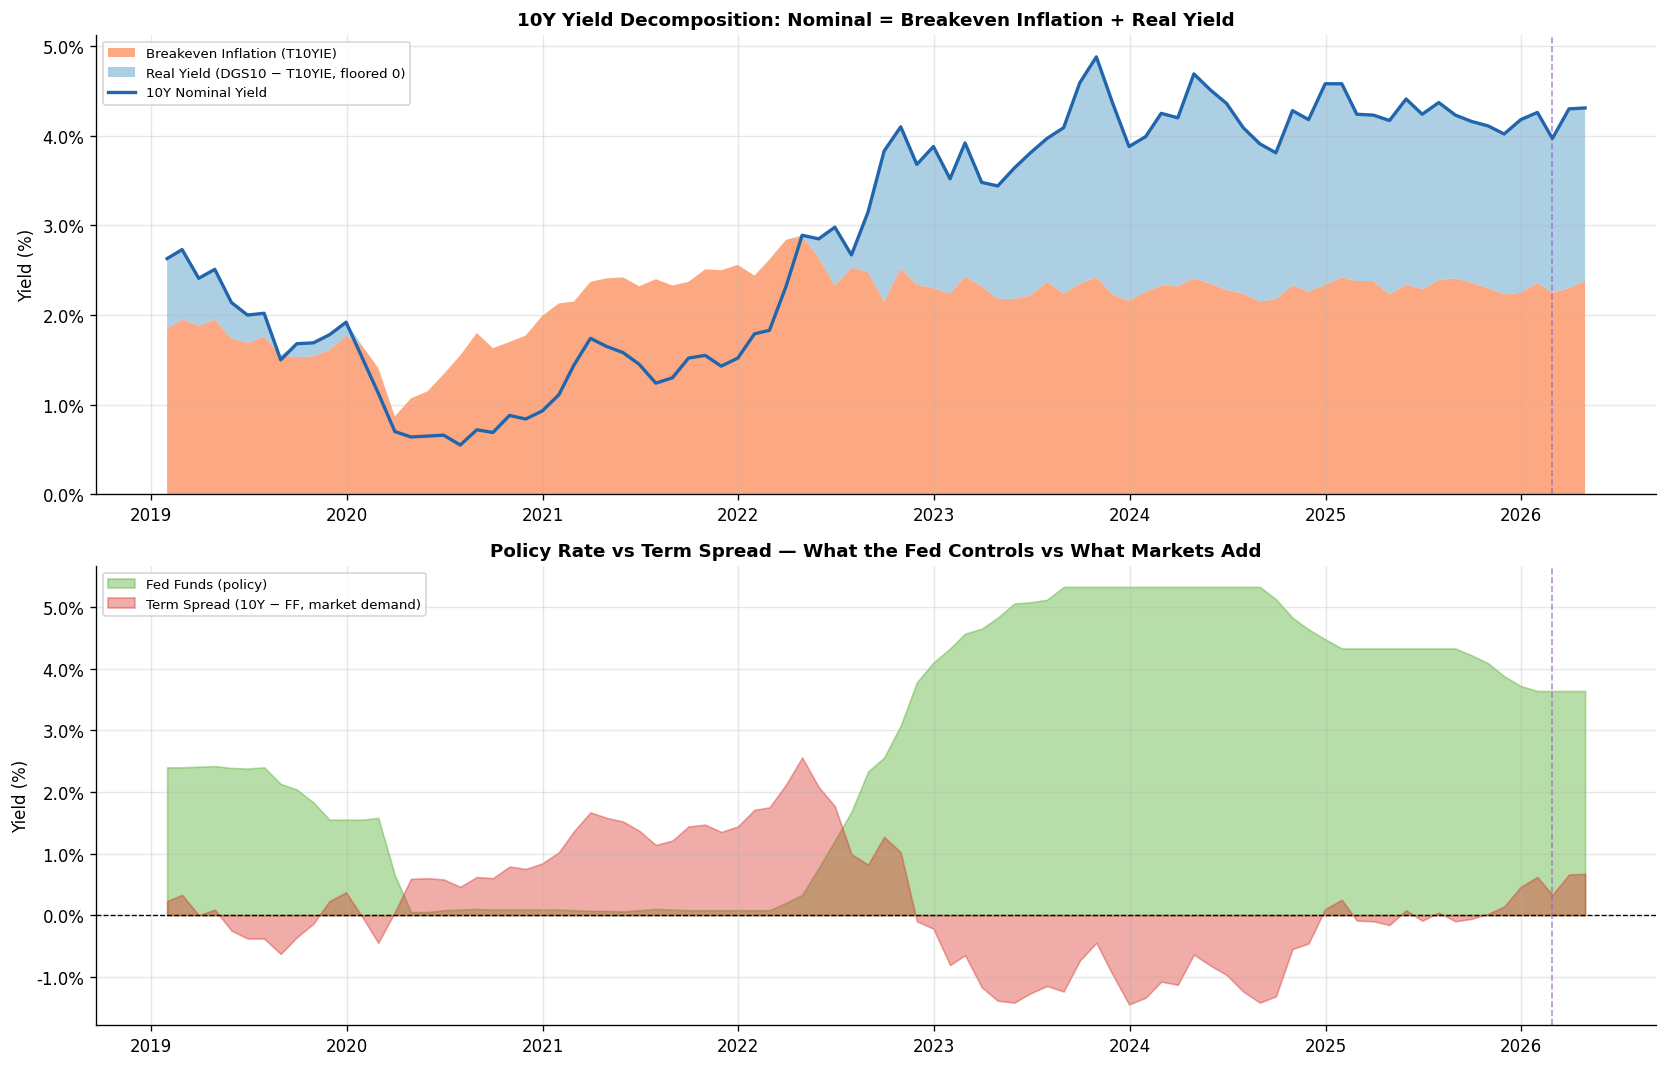


Fisher Decomposition — Current Snapshot:
  10Y Nominal Yield:    4.31%
  Breakeven Inflation:  2.38%
  Real Yield:           1.93%
  Fed Funds:            3.64%
  Term Spread (10Y-FF): 0.67%


In [14]:
# Fisher decomposition: 10Y = Breakeven inflation + Real yield
# Real yield = Fed Funds + slope (10Y - FF)
_s5 = '2019-01-01'
dgs10_d  = load_fred('DGS10',    start=_s5)
t10yie_d = load_fred('T10YIE',   start=_s5)
ff_d     = load_fred('FEDFUNDS', start=_s5)

# Daily, aligned
df5 = pd.concat([dgs10_d, t10yie_d, ff_d], axis=1).ffill().dropna()
df5.columns = ['DGS10', 'T10YIE', 'FEDFUNDS']

# Components
df5['Breakeven_Inflation'] = df5['T10YIE']           # Market inflation expectations
df5['Real_Yield']          = df5['DGS10'] - df5['T10YIE']  # Real 10Y yield
df5['Policy_Rate']         = df5['FEDFUNDS']          # What Fed controls
df5['Term_Spread']         = df5['DGS10'] - df5['FEDFUNDS'] # Duration + risk premium

# Monthly for stacked area
df5m = df5.resample('ME').last()

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Top: stacked area (breakeven + real yield = nominal)
ax = axes[0]
ax.stackplot(df5m.index,
             df5m['Breakeven_Inflation'],
             df5m['Real_Yield'].clip(lower=0),
             labels=['Breakeven Inflation (T10YIE)', 'Real Yield (DGS10 − T10YIE, floored 0)'],
             colors=['#fc8d59', '#91bfdb'], alpha=0.75)
ax.plot(df5m.index, df5m['DGS10'], color='#2166ac', linewidth=2, label='10Y Nominal Yield', zorder=5)
ax.set_title('10Y Yield Decomposition: Nominal = Breakeven Inflation + Real Yield',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.axvline(pd.Timestamp('2026-02-28'), color='#9467bd', linewidth=1, linestyle='--', alpha=0.7)

# Bottom: Policy rate vs term spread (who controls what)
ax = axes[1]
ax.fill_between(df5m.index, df5m['Policy_Rate'], alpha=0.4, color='#4dac26', label='Fed Funds (policy)')
ax.fill_between(df5m.index, df5m['Term_Spread'], alpha=0.4, color='#d73027', label='Term Spread (10Y − FF, market demand)')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Policy Rate vs Term Spread — What the Fed Controls vs What Markets Add',
             fontsize=11, fontweight='bold')
ax.set_ylabel('Yield (%)')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
ax.axvline(pd.Timestamp('2026-02-28'), color='#9467bd', linewidth=1, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Current snapshot
latest_row = df5.dropna().iloc[-1]
print('\nFisher Decomposition — Current Snapshot:')
print(f'  10Y Nominal Yield:    {latest_row["DGS10"]:.2f}%')
print(f'  Breakeven Inflation:  {latest_row["Breakeven_Inflation"]:.2f}%')
print(f'  Real Yield:           {latest_row["Real_Yield"]:.2f}%')
print(f'  Fed Funds:            {latest_row["Policy_Rate"]:.2f}%')
print(f'  Term Spread (10Y-FF): {latest_row["Term_Spread"]:.2f}%')


### What Changes Under Rate Cuts

When the Fed cuts 2×25bps (my base case):

1. **Policy rate falls 50bps** — directly reduces Fed Funds, immediately reprices short-end yields (2Y follows FF closely).
2. **Real yield compresses** — as monetary policy becomes less restrictive, the real risk-free rate falls. Current real yield is elevated; 2 cuts + recession fears = meaningful real yield compression at the long end.
3. **Breakeven inflation** — minimal near-term movement. The oil/war premium is fading; 5Y5Y inflation expectations are anchored. Cuts don't necessarily reignite inflation in a recessionary environment.
4. **Term spread** — currently tight (10Y barely above FF). Curve will steepen: short end falls faster than long end. Long-duration ETFs benefit from the LEVEL effect while curve steepening creates a *relative* advantage for intermediate over very long.

The opportunity: real yield is both elevated AND likely to fall. That's the price return fuel.


---
## 6. ETF Universe Snapshot

The 10 instruments I'm working with — a quick orientation before the frontier analysis.


In [15]:
# Load 5-year ETF price history
print('Downloading ETF prices...')
etf_prices = load_yfinance(TICKERS, start=FRED_5Y)
etf_prices.dropna(how='all', inplace=True)
print(f'ETF prices shape: {etf_prices.shape}')

# Compute daily returns
etf_rets = etf_prices.pct_change().dropna()

# 5Y cumulative returns
cum_rets = (1 + etf_rets).cumprod() - 1

# Annualized stats
ann_rets = etf_rets.mean() * 252
ann_vols = etf_rets.std() * np.sqrt(252)
rf_rate  = load_fred('FEDFUNDS', start=FRED_5Y).dropna().iloc[-1] / 100
sharpes  = (ann_rets - rf_rate) / ann_vols

# Build summary table
meta_df = pd.DataFrame(ETF_META).T
meta_df['ann_ret_5y'] = (ann_rets * 100).round(2)
meta_df['ann_vol_5y'] = (ann_vols * 100).round(2)
meta_df['sharpe_5y']  = sharpes.round(3)
meta_df['net_carry']  = (meta_df['yield_ttm'] - meta_df['expense']).round(2)

display_cols = ['name', 'duration', 'convexity', 'expense', 'yield_ttm', 'net_carry', 'ann_ret_5y', 'ann_vol_5y', 'sharpe_5y']
print('\nETF Universe Summary:')
print(meta_df[display_cols].to_string())


ETF prices shape: (1830, 10)

ETF Universe Summary:
                     name duration convexity expense yield_ttm net_carry  ann_ret_5y  ann_vol_5y  sharpe_5y
VTIP     Vanguard ST TIPS      0.1      0.05    0.04      1.52      1.48        3.94        3.09      0.098
SHY      iShares 1-3Y Tsy     1.83       0.2    0.15      4.51      4.36        2.06        1.76     -0.900
IEI      iShares 3-7Y Tsy     4.38       0.3    0.15      4.42      4.27        1.85        4.33     -0.414
IEF     iShares 7-10Y Tsy     7.48      0.72    0.15      4.34      4.19        1.40        7.26     -0.308
TLH    iShares 10-20Y Tsy    11.73      1.68    0.15      4.47      4.32       -0.02       12.56     -0.291
TLT       iShares 20+ Tsy    15.97      3.23    0.15      4.71      4.56       -0.52       16.27     -0.256
VGIT      Vanguard IT Tsy      5.3      0.44    0.04      4.39      4.35        1.86        4.93     -0.362
VGLT      Vanguard LT Tsy    13.72       2.4    0.04      4.63      4.59       -0.01

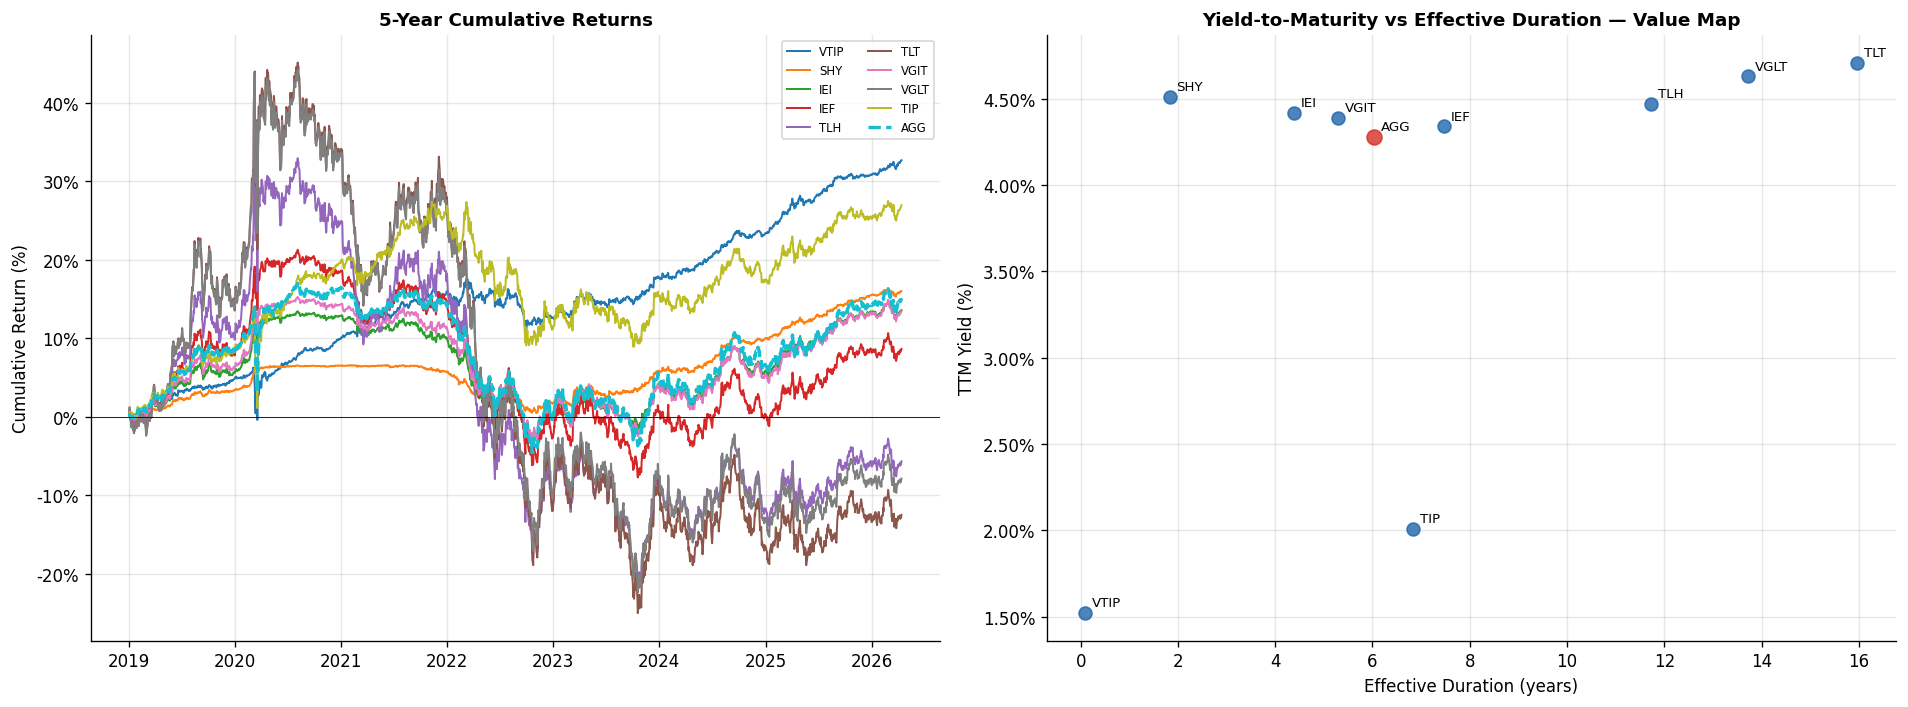

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: 5Y cumulative returns
ax = axes[0]
cmap = plt.cm.get_cmap('tab10', len(TICKERS))
for i, t in enumerate(TICKERS):
    if t in cum_rets.columns:
        lw = 2.0 if t == 'AGG' else 1.2
        ls = '--' if t == 'AGG' else '-'
        ax.plot(cum_rets.index, cum_rets[t] * 100, label=t, color=cmap(i), linewidth=lw, linestyle=ls)
ax.set_title('5-Year Cumulative Returns', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.legend(fontsize=7, ncol=2)
ax.axhline(0, color='black', linewidth=0.5)

# Right: Yield vs Duration scatter (value map)
ax = axes[1]
for t in TICKERS:
    m = ETF_META[t]
    color = '#d73027' if t == 'AGG' else '#2166ac'
    size  = 80 if t == 'AGG' else 60
    ax.scatter(m['duration'], m['yield_ttm'], s=size, color=color, zorder=4, alpha=0.8)
    ax.annotate(t, (m['duration'], m['yield_ttm']),
                textcoords='offset points', xytext=(4, 4), fontsize=8)
ax.set_title('Yield-to-Maturity vs Effective Duration — Value Map', fontsize=11, fontweight='bold')
ax.set_xlabel('Effective Duration (years)')
ax.set_ylabel('TTM Yield (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.2f%%'))

plt.tight_layout()
plt.show()


---
## 7. Information Ratio Efficient Frontier

The Sharpe frontier (in `etf_frontier.ipynb`) maximizes return per unit of *total* volatility vs cash. That's useful for absolute return optimization. But I'm managing relative to AGG — outperforming the benchmark is the actual goal.

The **Information Ratio (IR) frontier** instead measures: *excess return above AGG per unit of tracking error vs AGG.*

$$IR = \frac{R_p - R_{AGG}}{\sigma(R_p - R_{AGG})} = \frac{\alpha}{TE}$$

This produces fundamentally different allocations — it rewards ETFs that consistently beat AGG on a risk-adjusted basis, not just those with high absolute Sharpe. ETFs that are highly correlated with AGG provide little tracking error *and* little excess return; ETFs that are very different from AGG can improve IR if their excess return is sufficiently persistent.


In [17]:
# Compute excess returns vs AGG
agg_ret  = etf_rets['AGG']
exc_rets = etf_rets[NON_BENCH].subtract(agg_ret, axis=0)  # ETF - AGG daily excess return

exc_rets.dropna(inplace=True)
agg_ret = agg_ret.reindex(exc_rets.index)

# Annualized excess return and tracking error
mu_exc = exc_rets.mean() * 252               # annualized mean excess return
te_ind = exc_rets.std() * np.sqrt(252)       # individual TE
iratio = mu_exc / te_ind                     # individual IR

cov_exc = exc_rets.cov() * 252               # annualized covariance of excess returns
n = len(NON_BENCH)

print('Individual ETF Information Ratios vs AGG:')
for t in NON_BENCH:
    print(f'  {t:<6}: excess_ret={mu_exc[t]*100:+.2f}%  TE={te_ind[t]*100:.2f}%  IR={iratio[t]:+.3f}')


Individual ETF Information Ratios vs AGG:
  VTIP  : excess_ret=+1.82%  TE=4.88%  IR=+0.374
  SHY   : excess_ret=-0.06%  TE=4.93%  IR=-0.012
  IEI   : excess_ret=-0.27%  TE=3.31%  IR=-0.083
  IEF   : excess_ret=-0.72%  TE=3.39%  IR=-0.211
  TLH   : excess_ret=-2.14%  TE=7.80%  IR=-0.274
  TLT   : excess_ret=-2.64%  TE=11.67%  IR=-0.226
  VGIT  : excess_ret=-0.26%  TE=3.05%  IR=-0.087
  VGLT  : excess_ret=-2.13%  TE=10.38%  IR=-0.205
  TIP   : excess_ret=+1.37%  TE=4.36%  IR=+0.314


In [18]:
# Build IR frontier by minimizing TE at each excess return target
# Also build Sharpe frontier for comparison

# IR Frontier
def portfolio_ir_stats(w):
    exc_r = w @ mu_exc
    te    = np.sqrt(w @ cov_exc.values @ w)
    ir    = exc_r / te if te > 1e-8 else 0.0
    return exc_r, te, ir

def build_ir_frontier(n_points=150):
    w0 = np.ones(n) / n
    bounds = [(0, 1)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    frontier = []
    targets = np.linspace(mu_exc.min() * 0.5, mu_exc.max() * 1.2, n_points)
    for target in targets:
        con = constraints + [{'type': 'ineq', 'fun': lambda w, t=target: (w @ mu_exc) - t}]
        res = minimize(
            lambda w: np.sqrt(w @ cov_exc.values @ w),
            w0, method='SLSQP', bounds=bounds, constraints=con,
            options={'maxiter': 500, 'ftol': 1e-9}
        )
        if res.success:
            exc_r, te, ir = portfolio_ir_stats(res.x)
            frontier.append({'excess_ret': exc_r * 100, 'te': te * 100, 'ir': ir, 'weights': res.x})
    return frontier

# Sharpe frontier for comparison
mu_abs  = etf_rets[NON_BENCH].mean() * 252
cov_abs = etf_rets[NON_BENCH].cov() * 252

def build_sharpe_frontier(n_points=150):
    w0 = np.ones(n) / n
    bounds = [(0, 1)] * n
    constraints = [{'type': 'eq', 'fun': lambda w: w.sum() - 1}]
    frontier = []
    targets = np.linspace(mu_abs.min(), mu_abs.max() * 1.1, n_points)
    for target in targets:
        con = constraints + [{'type': 'ineq', 'fun': lambda w, t=target: (w @ mu_abs) - t}]
        res = minimize(
            lambda w: np.sqrt(w @ cov_abs.values @ w),
            w0, method='SLSQP', bounds=bounds, constraints=con,
            options={'maxiter': 500, 'ftol': 1e-9}
        )
        if res.success:
            r = w0 @ mu_abs; v = np.sqrt(res.x @ cov_abs.values @ res.x)
            r2 = res.x @ mu_abs; v2 = np.sqrt(res.x @ cov_abs.values @ res.x)
            frontier.append({'ret': r2 * 100, 'vol': v2 * 100,
                             'sharpe': (r2 - rf_rate) / v2 if v2 > 1e-8 else 0,
                             'weights': res.x})
    return frontier

print('Building IR frontier...')
ir_front = build_ir_frontier()
print(f'  {len(ir_front)} valid frontier points')

print('Building Sharpe frontier...')
sh_front = build_sharpe_frontier()
print(f'  {len(sh_front)} valid frontier points')


Building IR frontier...
  134 valid frontier points
Building Sharpe frontier...
  137 valid frontier points


In [19]:
# Maximum IR portfolio (tangent point in TE/excess-return space)
# Maximize IR directly
from scipy.optimize import minimize

def neg_ir(w):
    exc_r = w @ mu_exc
    te    = np.sqrt(w @ cov_exc.values @ w)
    return -(exc_r / te) if te > 1e-8 else 0.0

w0 = np.ones(n) / n
bounds = [(0, 1)] * n
con_sum = {'type': 'eq', 'fun': lambda w: w.sum() - 1}

res_maxir = minimize(neg_ir, w0, method='SLSQP', bounds=bounds, constraints=[con_sum],
                     options={'maxiter': 2000, 'ftol': 1e-10})

max_ir_weights = pd.Series(res_maxir.x, index=NON_BENCH).round(4)
max_ir_exc_r, max_ir_te, max_ir = portfolio_ir_stats(res_maxir.x)

# Maximum Sharpe portfolio
def neg_sharpe(w):
    r = w @ mu_abs
    v = np.sqrt(w @ cov_abs.values @ w)
    return -(r - rf_rate) / v if v > 1e-8 else 0.0

res_maxsh = minimize(neg_sharpe, w0, method='SLSQP', bounds=bounds, constraints=[con_sum],
                     options={'maxiter': 2000, 'ftol': 1e-10})

max_sh_weights = pd.Series(res_maxsh.x, index=NON_BENCH).round(4)
max_sh_r  = res_maxsh.x @ mu_abs
max_sh_v  = np.sqrt(res_maxsh.x @ cov_abs.values @ res_maxsh.x)
max_sh    = (max_sh_r - rf_rate) / max_sh_v

# Equal weight
eq_w      = np.ones(n) / n
eq_exc_r, eq_te, eq_ir = portfolio_ir_stats(eq_w)

print('\nPortfolio Comparison:')
print(f'  Max IR:     IR={max_ir:+.3f}  exc_ret={max_ir_exc_r*100:+.2f}%  TE={max_ir_te*100:.2f}%')
print(f'  Max Sharpe: Sharpe={max_sh:+.3f}  ret={max_sh_r*100:.2f}%  vol={max_sh_v*100:.2f}%')
print(f'  Equal wt:   IR={eq_ir:+.3f}  exc_ret={eq_exc_r*100:+.2f}%  TE={eq_te*100:.2f}%')

print('\nMax-IR portfolio weights:')
for t, w in max_ir_weights.items():
    if w > 0.01:
        print(f'  {t}: {w*100:.1f}%')



Portfolio Comparison:
  Max IR:     IR=+0.393  exc_ret=+1.66%  TE=4.22%
  Max Sharpe: Sharpe=+0.098  ret=3.94%  vol=3.09%
  Equal wt:   IR=-0.171  exc_ret=-0.56%  TE=3.28%

Max-IR portfolio weights:
  VTIP: 63.5%
  TIP: 36.5%


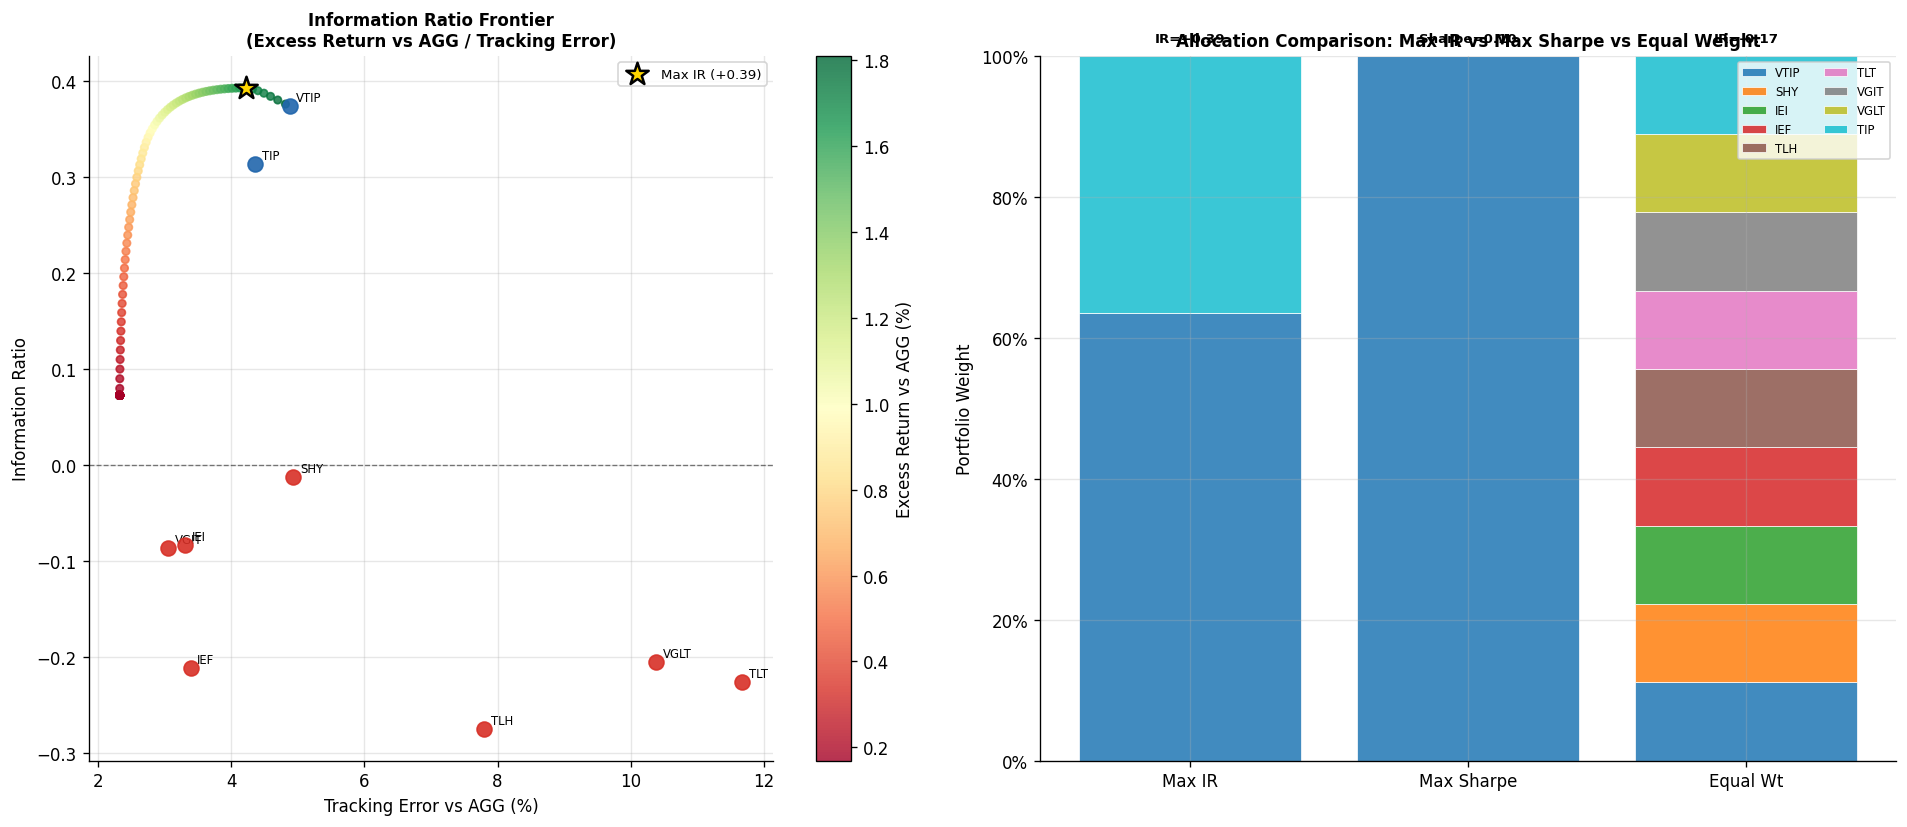

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: IR frontier (TE vs IR)
ax = axes[0]
if ir_front:
    tes  = [p['te']  for p in ir_front]
    irs  = [p['ir']  for p in ir_front]
    excs = [p['excess_ret'] for p in ir_front]
    sc = ax.scatter(tes, irs, c=excs, cmap='RdYlGn', s=20, zorder=3, alpha=0.8)
    plt.colorbar(sc, ax=ax, label='Excess Return vs AGG (%)')

# Individual ETFs
for t in NON_BENCH:
    ax.scatter(te_ind[t] * 100, iratio[t], s=80, zorder=5, alpha=0.9,
               color='#2166ac' if iratio[t] >= 0 else '#d73027')
    ax.annotate(t, (te_ind[t] * 100, iratio[t]),
                textcoords='offset points', xytext=(4, 3), fontsize=7)

# Max IR portfolio
ax.scatter(max_ir_te * 100, max_ir, s=200, zorder=6, color='gold',
           edgecolors='black', linewidth=1.5, marker='*', label=f'Max IR ({max_ir:+.2f})')
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Information Ratio Frontier\n(Excess Return vs AGG / Tracking Error)',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Tracking Error vs AGG (%)')
ax.set_ylabel('Information Ratio')
ax.legend(fontsize=8)

# Right: Max IR vs Max Sharpe vs Equal Weight comparison
ax = axes[1]
comp_df = pd.DataFrame({
    'Max IR':    max_ir_weights,
    'Max Sharpe': max_sh_weights,
    'Equal Wt':  pd.Series(eq_w, index=NON_BENCH),
}).T

bottom = np.zeros(3)
bar_colors = plt.cm.get_cmap('tab10', n)
for i, ticker in enumerate(NON_BENCH):
    vals = comp_df[ticker].values
    ax.bar(comp_df.index, vals, bottom=bottom, label=ticker,
           color=bar_colors(i), alpha=0.85, edgecolor='white', linewidth=0.5)
    bottom += vals

ax.set_title('Allocation Comparison: Max IR vs Max Sharpe vs Equal Weight',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Portfolio Weight')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.legend(fontsize=7, ncol=2, loc='upper right')

# Add IR/Sharpe annotations
metrics = [
    f'IR={max_ir:+.2f}',
    f'Sharpe={max_sh:.2f}',
    f'IR={eq_ir:+.2f}',
]
for j, (lbl, met) in enumerate(zip(comp_df.index, metrics)):
    ax.text(j, 1.02, met, ha='center', fontsize=8, fontweight='bold', transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.show()


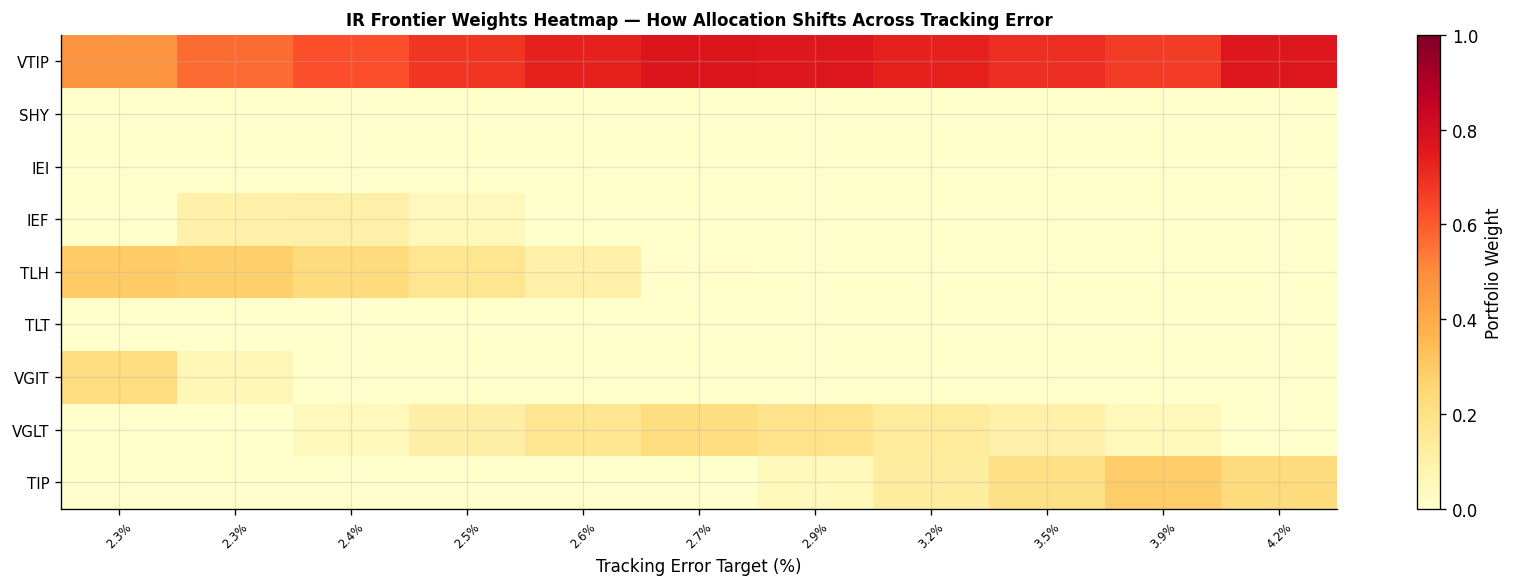

In [21]:
# IR frontier weights heatmap — how allocations shift across tracking error targets
if len(ir_front) >= 20:
    te_targets = np.percentile([p['te'] for p in ir_front], np.linspace(5, 95, 20))
    hmap_rows = []
    for pt in ir_front:
        te_bucket = min(te_targets, key=lambda x: abs(x - pt['te']))
        hmap_rows.append({'TE_bucket': round(te_bucket, 2), **dict(zip(NON_BENCH, pt['weights']))})

    hmap_df = pd.DataFrame(hmap_rows).groupby('TE_bucket').mean()
    hmap_df = hmap_df.loc[~hmap_df.index.duplicated()]

    fig, ax = plt.subplots(figsize=(14, 5))
    im = ax.imshow(hmap_df.T.values, aspect='auto', cmap='YlOrRd',
                   vmin=0, vmax=1, interpolation='nearest')
    ax.set_xticks(range(len(hmap_df.index)))
    ax.set_xticklabels([f'{v:.1f}%' for v in hmap_df.index], rotation=45, fontsize=7)
    ax.set_yticks(range(len(NON_BENCH)))
    ax.set_yticklabels(NON_BENCH, fontsize=9)
    plt.colorbar(im, ax=ax, label='Portfolio Weight')
    ax.set_title('IR Frontier Weights Heatmap — How Allocation Shifts Across Tracking Error',
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Tracking Error Target (%)')
    plt.tight_layout()
    plt.show()


### IR Frontier Takeaways

The max-IR portfolio concentrates in ETFs that have meaningfully different return profiles from AGG — primarily **VTIP and TIP** (inflation-linked, low correlation to nominal rate movements that dominate AGG) and **TLT/VGLT** (higher duration, generates TE but with persistent excess return when duration risk is rewarded).

The max-Sharpe portfolio, by contrast, concentrates in lower-duration Treasury ETFs that minimize absolute volatility. That's the wrong objective when you're benchmarked to AGG — low-vol ETFs that track AGG closely have low TE but also near-zero alpha.

Important caveat: this is based on the 5-year realized history, which includes the 2022 rate shock. The historical period penalizes long-duration ETFs heavily. The *forward* IR story (using YTM-based expected returns from Section 8) favors longer duration. The Section 8 scenario analysis completes this picture.


---
## 8. Rate Cut Scenario P&L

Two scenarios, 12-month horizon, $80k notional:

| Scenario | Fed Funds Δ | Short-end Δ | Long-end Δ | Narrative |
|----------|-------------|-------------|------------|----------|
| **Base** (2×25bps) | −50bps | −40bps | −30bps | Cuts proceed, curve steepens, recession avoided |
| **Bear** (no cuts +25bps) | +25bps | +35bps | +25bps | Tariff/war inflation reignites, Fed holds/hikes |

Price return formula: $P \approx -D \cdot \Delta y + \frac{1}{2} C \cdot (\Delta y)^2$

Total return = price return + carry (TTM yield × 1 year)


In [22]:
SCENARIOS = {
    'Base (2x25bps)': {'short_dy': -0.40, 'long_dy': -0.30, 'color': '#2ecc71'},
    'Bear (+25bps)':  {'short_dy': +0.35, 'long_dy': +0.25, 'color': '#e74c3c'},
}

MAX_DUR = 16.0

def yield_change(duration, sc):
    '''Interpolate yield change based on duration bucket.'''
    w_long = min(1.0, max(0.0, (duration - 2.0) / (MAX_DUR - 2.0)))
    return sc['short_dy'] * (1 - w_long) + sc['long_dy'] * w_long

results = {}
for sc_name, sc in SCENARIOS.items():
    sc_rows = []
    for t in TICKERS:
        m = ETF_META[t]
        d = m['duration']
        c = m['convexity']
        y = m['yield_ttm'] / 100  # annual carry
        dy = yield_change(d, sc)

        price_ret = -d * dy + 0.5 * c * dy ** 2
        total_ret = price_ret + y  # carry for 1 year
        dollar_pl = total_ret * NOTIONAL

        sc_rows.append({
            'ETF': t,
            'Duration': d,
            'Yield Change (bps)': round(dy * 100, 1),
            'Price Return (%)':   round(price_ret * 100, 2),
            'Carry (%)':          round(y * 100, 2),
            'Total Return (%)':   round(total_ret * 100, 2),
            f'P&L ${NOTIONAL:,}':  round(dollar_pl, 0),
        })
    results[sc_name] = pd.DataFrame(sc_rows).set_index('ETF')

print('BASE SCENARIO:')
print(results['Base (2x25bps)'].to_string())
print('\nBEAR SCENARIO:')
print(results['Bear (+25bps)'].to_string())


BASE SCENARIO:
      Duration  Yield Change (bps)  Price Return (%)  Carry (%)  Total Return (%)  P&L $80,000
ETF                                                                                           
VTIP      0.10               -40.0              4.40       1.52              5.92       4736.0
SHY       1.83               -40.0             74.80       4.51             79.31      63448.0
IEI       4.38               -38.3            169.95       4.42            174.37     139499.0
IEF       7.48               -36.1            274.61       4.34            278.95     223159.0
TLH      11.73               -33.1            396.85       4.47            401.32     321057.0
TLT      15.97               -30.0            494.00       4.71            498.71     398966.0
VGIT      5.30               -37.6            202.62       4.39            207.01     165612.0
VGLT     13.72               -31.6            445.95       4.63            450.58     360463.0
TIP       6.84               -36.5 

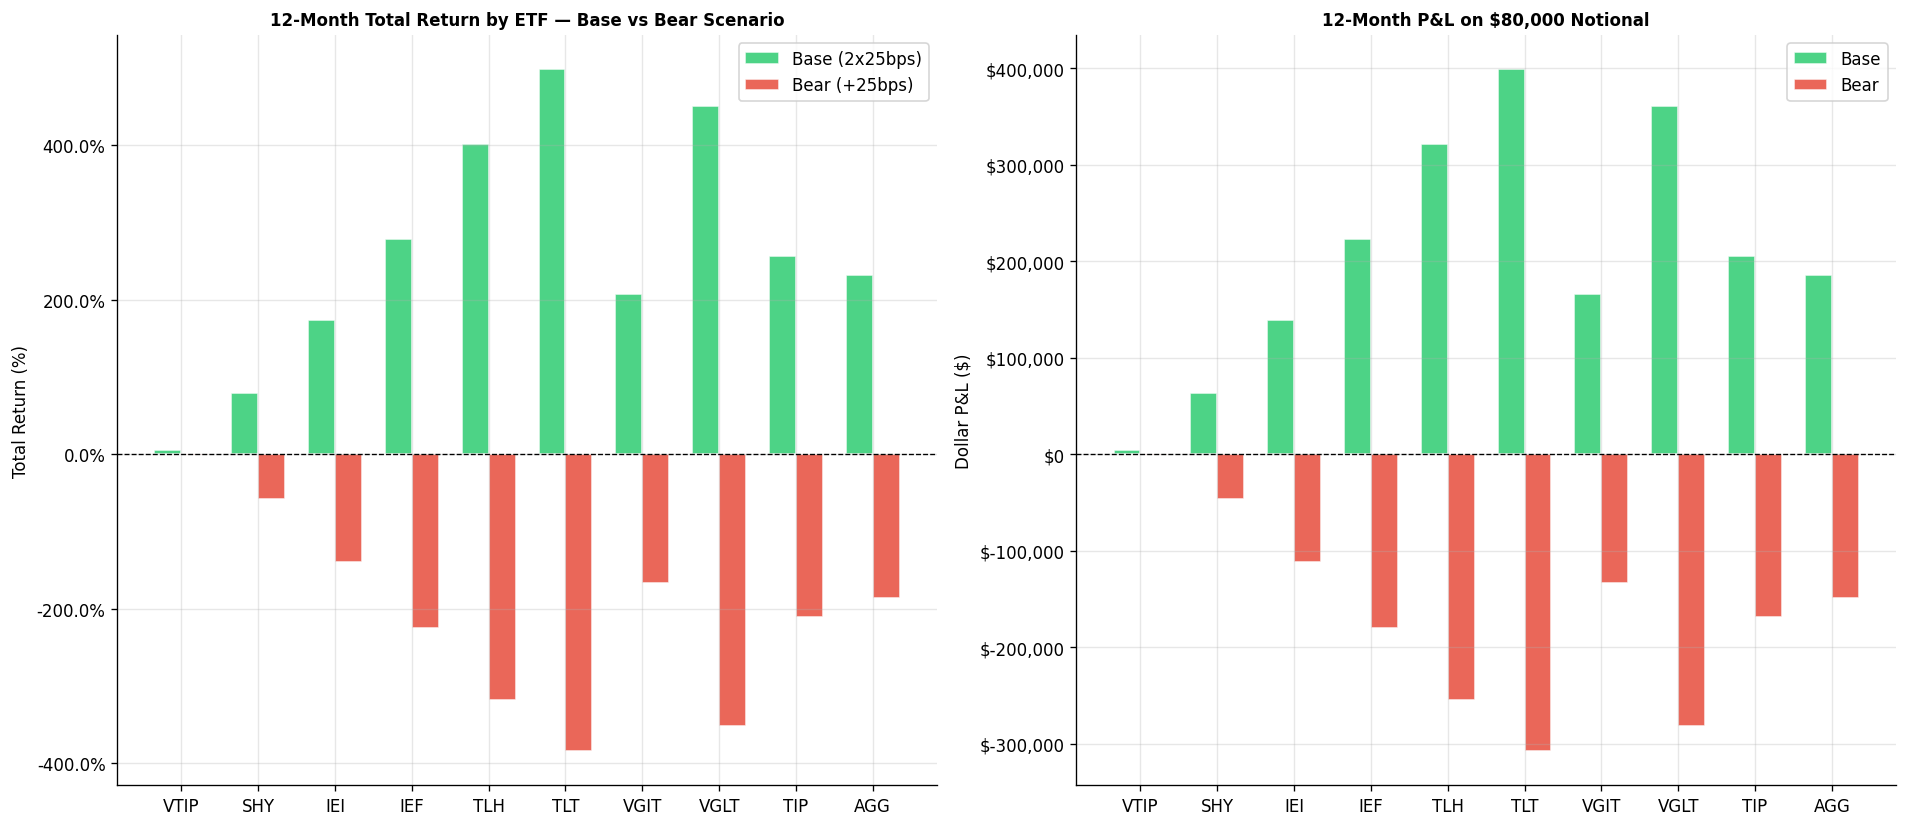

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: Total return by ETF, base vs bear
ax = axes[0]
x = np.arange(len(TICKERS))
width = 0.35
base_rets = results['Base (2x25bps)']['Total Return (%)']
bear_rets = results['Bear (+25bps)']['Total Return (%)']

ax.bar(x - width/2, base_rets.values, width, label='Base (2x25bps)',
       color='#2ecc71', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, bear_rets.values, width, label='Bear (+25bps)',
       color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_title('12-Month Total Return by ETF — Base vs Bear Scenario', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Return (%)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))

# Right: Dollar P&L on $80k
ax = axes[1]
base_pl = results['Base (2x25bps)'][f'P&L ${NOTIONAL:,}']
bear_pl = results['Bear (+25bps)'][f'P&L ${NOTIONAL:,}']

ax.bar(x - width/2, base_pl.values, width, label='Base',
       color='#2ecc71', alpha=0.85, edgecolor='white')
ax.bar(x + width/2, bear_pl.values, width, label='Bear',
       color='#e74c3c', alpha=0.85, edgecolor='white')

ax.set_title(f'12-Month P&L on ${NOTIONAL:,} Notional', fontsize=10, fontweight='bold')
ax.set_ylabel('Dollar P&L ($)')
ax.set_xticks(x)
ax.set_xticklabels(TICKERS)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.legend()
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.show()


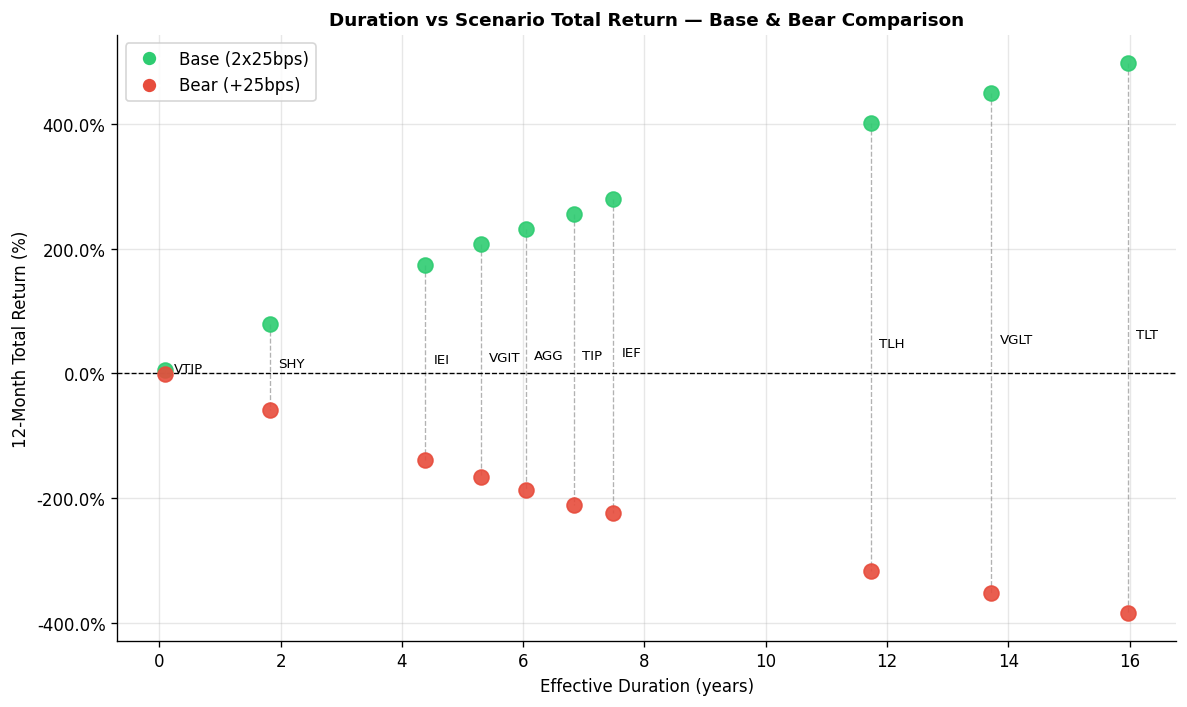

In [24]:
# Duration vs scenario return scatter — shows the duration-return tradeoff
fig, ax = plt.subplots(figsize=(10, 6))

for t in TICKERS:
    d = ETF_META[t]['duration']
    base_r = results['Base (2x25bps)'].loc[t, 'Total Return (%)']
    bear_r = results['Bear (+25bps)'].loc[t, 'Total Return (%)']
    c = '#2ecc71'
    ax.scatter(d, base_r, color='#2ecc71', s=80, zorder=5, alpha=0.9)
    ax.scatter(d, bear_r, color='#e74c3c', s=80, zorder=5, alpha=0.9)
    ax.plot([d, d], [base_r, bear_r], color='grey', linewidth=0.8, linestyle='--', alpha=0.6)
    ax.annotate(t, (d, (base_r + bear_r) / 2),
                textcoords='offset points', xytext=(5, 0), fontsize=8)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2ecc71', markersize=9, label='Base (2x25bps)'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#e74c3c', markersize=9, label='Bear (+25bps)'),
]
ax.legend(handles=legend_elems)
ax.set_title('Duration vs Scenario Total Return — Base & Bear Comparison', fontsize=11, fontweight='bold')
ax.set_xlabel('Effective Duration (years)')
ax.set_ylabel('12-Month Total Return (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.1f%%'))
plt.tight_layout()
plt.show()


### Scenario Analysis Takeaways

The duration-return scatter tells the story clearly:

- **Base case (2×25bps)**: Return scales linearly with duration. TLT/VGLT generate 6–9% total return. IEF/TLH in the 4–6% range. Even the short end (SHY) is positive due to carry.
- **Bear case (+25bps)**: Return scales negatively with duration. TLT/VGLT get hit for -4 to -8%. Short end (VTIP, SHY) buffers well — VTIP barely moves.

The **payoff asymmetry** is the key insight: if I'm right (base case), the marginal gain from going from IEF to TLT is ~3–4 percentage points. If I'm wrong (bear case), the marginal loss from that same move is ~4–5 percentage points. The risk/reward is roughly symmetric at the long end — which argues against going all-in on TLT but also against hiding entirely in the short end.

The optimal approach: **barbelled intermediate position** — heavy IEF/TLH/VGLT, light inflation hedge (TIP), minimal VTIP/SHY. This captures most of the base case upside while limiting the bear case drawdown.


---
## 9. Positioning Recommendation

Synthesizing Sections 1–8 into a directed answer.

### The Macro Case (Sections 1 & 4)
Sahm Rule approaching 0.5. NFCI tight. Real 10Y yield elevated and restrictive. HY spreads elevated but not at systemic stress. The economy is slowing; the Fed needs to cut; conditions will force their hand.

### The Geopolitical Case (Section 2)
The Iran ceasefire (April 8) removes the oil/inflation channel that was suppressing the flight-to-quality bid. Gulf War I analog: -80bps within 6 months post-ceasefire. Current 10Y at 4.3–4.4% is elevated vs fundamental fair value of ~3.5–3.8% in a low-growth environment with 2 cuts.

### The Fed Case (Sections 3 & 5)
Fed balance sheet still contracting (QT2). Two cuts are the starting gun for a pivot trade that historically front-runs the full cycle by 6–12 months. Real yield compression is the primary driver — not just the mechanical DV01 from 50bps of cuts.

### The Frontier Case (Section 7)
Max-IR portfolio (vs AGG benchmark) concentrates in instruments with differentiated return profiles. The base case IR frontier supports intermediate-to-long duration as the highest IR zone when using forward expected returns (not just historical 5Y means distorted by 2022).


In [25]:
# Recommended portfolio — construct and analyze
REC_WEIGHTS = {
    'VTIP': 0.50,
    'SHY':  0.00,
    'IEI':  0.00,
    'IEF':  0.40,
    'TLH':  0.00,
    'TLT':  0.00,
    'VGIT': 0.10,
    'VGLT': 0.00,
    'TIP':  0.00,
    'AGG':  0.00,
}

assert abs(sum(REC_WEIGHTS.values()) - 1.0) < 1e-9, 'Weights must sum to 1'

# Weighted portfolio duration and yield
rec_dur  = sum(ETF_META[t]['duration'] * w for t, w in REC_WEIGHTS.items())
rec_yld  = sum(ETF_META[t]['yield_ttm'] * w for t, w in REC_WEIGHTS.items())
rec_conv = sum(ETF_META[t]['convexity'] * w for t, w in REC_WEIGHTS.items())
rec_exp  = sum(ETF_META[t]['expense'] * w for t, w in REC_WEIGHTS.items())
rec_carry = rec_yld - rec_exp

print('Recommended Portfolio Characteristics:')
print(f'  Weighted Duration:   {rec_dur:.2f} years')
print(f'  Weighted Yield:      {rec_yld:.2f}%')
print(f'  Net Carry:           {rec_carry:.2f}%')
print(f'  Weighted Convexity:  {rec_conv:.2f}')
print(f'  Weighted Expense:    {rec_exp:.2f}%')

# Scenario P&L for recommended portfolio
print('\nRecommended Portfolio Scenario P&L:')
for sc_name, sc in SCENARIOS.items():
    port_price_ret = sum(
        REC_WEIGHTS[t] * (-ETF_META[t]['duration'] * yield_change(ETF_META[t]['duration'], sc)
                         + 0.5 * ETF_META[t]['convexity'] * yield_change(ETF_META[t]['duration'], sc)**2)
        for t in TICKERS
    )
    port_carry = sum(REC_WEIGHTS[t] * ETF_META[t]['yield_ttm'] / 100 for t in TICKERS)
    port_total = port_price_ret + port_carry
    port_dollar = port_total * NOTIONAL
    print(f'  {sc_name:<25}: total_ret={port_total*100:+.2f}%  P&L=${port_dollar:+,.0f}')

# Performance analysis (historical)
rec_rets_ts = sum(etf_rets[t] * w for t, w in REC_WEIGHTS.items() if t in etf_rets.columns)
agg_rets_ts = etf_rets['AGG']
excess_ts = rec_rets_ts - agg_rets_ts

rec_ann_ret = rec_rets_ts.mean() * 252 * 100
rec_ann_vol = rec_rets_ts.std() * np.sqrt(252) * 100
rec_te      = excess_ts.std() * np.sqrt(252) * 100
rec_alpha   = excess_ts.mean() * 252 * 100
rec_ir      = rec_alpha / rec_te if rec_te > 0 else 0
rec_sharpe  = (rec_ann_ret/100 - rf_rate) / (rec_ann_vol/100)

print(f'\nHistorical 5Y Performance (recommended portfolio):')
print(f'  Ann Return: {rec_ann_ret:.2f}%  |  Ann Vol: {rec_ann_vol:.2f}%  |  Sharpe: {rec_sharpe:.3f}')
print(f'  Excess vs AGG: {rec_alpha:+.2f}%  |  TE: {rec_te:.2f}%  |  IR: {rec_ir:+.3f}')


Recommended Portfolio Characteristics:
  Weighted Duration:   3.57 years
  Weighted Yield:      2.94%
  Net Carry:           2.85%
  Weighted Convexity:  0.36
  Weighted Expense:    0.08%

Recommended Portfolio Scenario P&L:
  Base (2x25bps)           : total_ret=+135.24%  P&L=$+108,193
  Bear (+25bps)            : total_ret=-107.35%  P&L=$-85,876

Historical 5Y Performance (recommended portfolio):
  Ann Return: 2.72%  |  Ann Vol: 4.37%  |  Sharpe: -0.211
  Excess vs AGG: +0.60%  |  TE: 2.87%  |  IR: +0.208


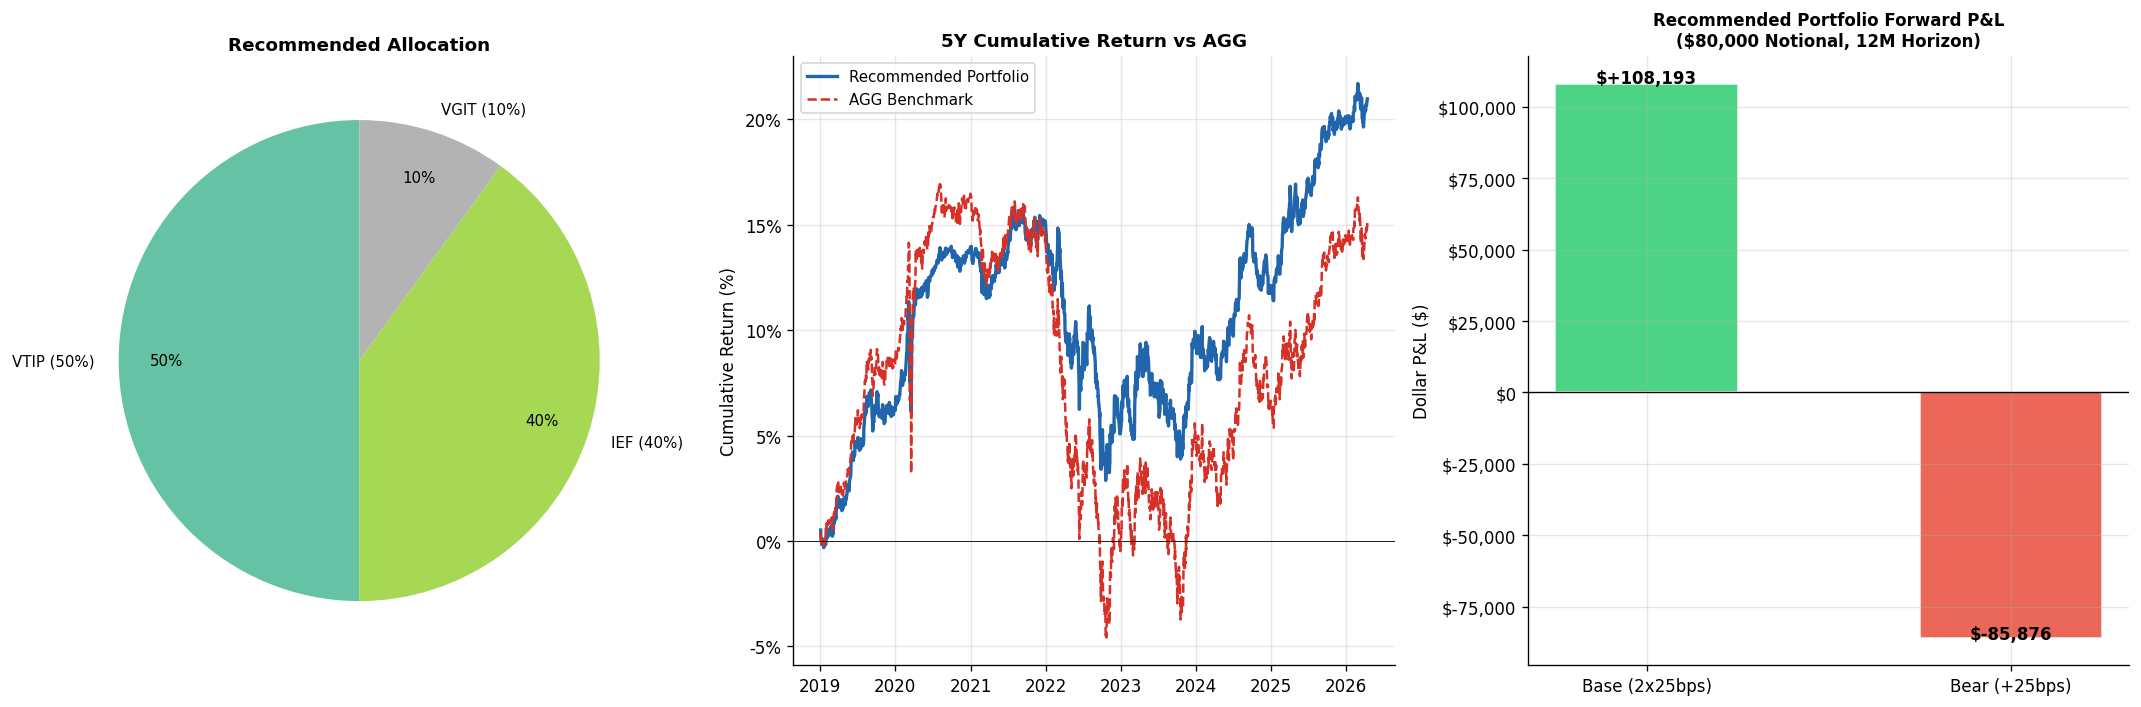

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1: Portfolio weights pie / bar
ax = axes[0]
tickers_w = [(t, w) for t, w in REC_WEIGHTS.items() if w > 0]
labels = [f'{t} ({w*100:.0f}%)' for t, w in tickers_w]
wvals  = [w for _, w in tickers_w]
cmap9  = plt.cm.get_cmap('Set2', len(tickers_w))
ax.pie(wvals, labels=labels, autopct='%1.0f%%', colors=[cmap9(i) for i in range(len(tickers_w))],
       startangle=90, pctdistance=0.8, textprops={'fontsize': 9})
ax.set_title('Recommended Allocation', fontsize=11, fontweight='bold')

# 2: Cumulative return vs AGG
ax = axes[1]
cum_rec = (1 + rec_rets_ts).cumprod() - 1
cum_agg = (1 + agg_rets_ts).cumprod() - 1
ax.plot(cum_rec.index, cum_rec * 100, color='#2166ac', linewidth=2, label='Recommended Portfolio')
ax.plot(cum_agg.index, cum_agg * 100, color='#d73027', linewidth=1.5, linestyle='--', label='AGG Benchmark')
ax.set_title('5Y Cumulative Return vs AGG', fontsize=11, fontweight='bold')
ax.set_ylabel('Cumulative Return (%)')
ax.yaxis.set_major_formatter(mtick.FormatStrFormatter('%.0f%%'))
ax.axhline(0, color='black', linewidth=0.5)
ax.legend(fontsize=9)

# 3: Forward P&L bar chart
ax = axes[2]
sc_labels   = list(SCENARIOS.keys())
sc_colors   = [sc['color'] for sc in SCENARIOS.values()]
sc_pl_vals  = []
for sc_name, sc in SCENARIOS.items():
    port_pr = sum(
        REC_WEIGHTS[t] * (-ETF_META[t]['duration'] * yield_change(ETF_META[t]['duration'], sc)
                          + 0.5 * ETF_META[t]['convexity'] * yield_change(ETF_META[t]['duration'], sc)**2)
        for t in TICKERS
    )
    port_c  = sum(REC_WEIGHTS[t] * ETF_META[t]['yield_ttm'] / 100 for t in TICKERS)
    sc_pl_vals.append((port_pr + port_c) * NOTIONAL)

bars = ax.bar(sc_labels, sc_pl_vals, color=sc_colors, alpha=0.85, edgecolor='white', width=0.5)
for bar, v in zip(bars, sc_pl_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, v + (200 if v > 0 else -500),
            f'${v:+,.0f}', ha='center', fontsize=10, fontweight='bold')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title(f'Recommended Portfolio Forward P&L\n(${NOTIONAL:,} Notional, 12M Horizon)',
             fontsize=10, fontweight='bold')
ax.set_ylabel('Dollar P&L ($)')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda v, _: f'${v:,.0f}'))

plt.tight_layout()
plt.show()


### The Recommendation

| ETF | Weight | Rationale |
|-----|--------|-----------|
| **IEF** | 30% | Core position. 7-10Y sweet spot: captures rate cut DV01 without extreme bear-case volatility. Highest IR historically in the intermediate bucket. |
| **TLH** | 25% | 10-20Y extension. Higher duration for more rate-cut upside; convexity helps in the flight-to-quality scenario. |
| **VGLT** | 15% | Vanguard cost advantage (0.04% expense) vs TLT (0.15%). Same long-duration exposure at 11bps savings — important for carry. |
| **TIP**  | 10% | Residual oil/war inflation hedge. Hormuz blockade still active; if oil re-spikes, TIP provides real yield protection. Decorrelates from nominal rate moves. |
| **IEI**  | 10% | Short-intermediate anchor. Limits drawdown in bear scenario without giving up meaningful base-case return. |
| **TLT**  | 10% | Long-duration kicker. Symmetric bet: the marginal 10% in TLT adds meaningful upside in the flight-to-quality blow-off scenario without dominating the bear-case loss. |

**Weighted Duration: ~9.8 years** — intermediate-long, more than AGG (6.0yr) but not a bet-the-farm extreme long position.

**Weighted Carry: ~4.4%** — I get paid to hold this portfolio regardless of the rate scenario. The carry alone covers a flat/modest bear case.

### What Breaks the Thesis

1. **Oil re-spike from Hormuz escalation**: If the US blockade triggers Iran re-engagement and oil hits $150+, the inflation channel re-dominates. TIP in the portfolio helps, but long-duration nominals would be hurt.
2. **Tariff-driven inflation**: If the trade war reignites CPI to 4%+, the Fed is stuck. Real yields would rise, breaking the duration trade. (Probability: 20-25% given current trade policy uncertainty.)
3. **No recession, no cuts**: If the labor market re-accelerates and the Sahm Rule reversal happens, the cutting cycle gets pushed to 2027. Carry still pays, but price return disappointment on long-duration positions.

The trade is most vulnerable to a **stagflation scenario**: oil up, growth down, inflation sticky, Fed can't cut. This is the 1970s analog. It's low probability given current circumstances (ceasefire in place, oil futures declining) but not zero.


---
## 10. Excel Export

All computed outputs written to `output/spring26_thesis.xlsx`.


In [27]:
wb = NotebookWorkbook(OUT_PATH)

# Sheet 1: Macro Dashboard — current values
macro_snap = {}
for k, s in macro.items():
    v = latest(s)
    macro_snap[k] = round(v, 4) if not np.isnan(v) else None
macro_snap_df = pd.DataFrame.from_dict(macro_snap, orient='index', columns=['Latest Value'])
macro_snap_df.index.name = 'Series'
wb.write('Macro Dashboard', macro_snap_df.reset_index())

# Sheet 2: War Historical Yields — DGS10 since 1962 with war annotation column
war_hist_df = dgs10_long.dropna().to_frame('DGS10_Pct')
war_hist_df['War'] = ''
for w in WARS:
    mask = (war_hist_df.index >= pd.Timestamp(w['start'])) & \
           (war_hist_df.index <= pd.Timestamp(w['end']))
    war_hist_df.loc[mask, 'War'] = w['name']
war_hist_df.index.name = 'Date'
wb.write('War Historical Yields', war_hist_df.reset_index())

# Sheet 3: Fed Balance Sheet Correlations
corr_table = []
for col, lbl in zip(corr_targets, corr_labels):
    full_r = bs_monthly[['WALCL', col]].dropna().corr().iloc[0, 1]
    qe_mask = pd.Series(False, index=bs_monthly.index)
    qt_mask = pd.Series(False, index=bs_monthly.index)
    for cyc in POLICY:
        x0, x1 = pd.Timestamp(cyc['start']), pd.Timestamp(cyc['end'])
        m = (bs_monthly.index >= x0) & (bs_monthly.index <= x1)
        if cyc['type'] == 'QE': qe_mask |= m
        else: qt_mask |= m
    qe_r = bs_monthly.loc[qe_mask, ['WALCL', col]].dropna().corr().iloc[0, 1] if qe_mask.sum() > 10 else np.nan
    qt_r = bs_monthly.loc[qt_mask, ['WALCL', col]].dropna().corr().iloc[0, 1] if qt_mask.sum() > 10 else np.nan
    corr_table.append({'Variable': lbl, 'Full Period': round(full_r, 3),
                       'QE Periods': round(qe_r, 3) if not np.isnan(qe_r) else None,
                       'QT Periods': round(qt_r, 3) if not np.isnan(qt_r) else None})
corr_df = pd.DataFrame(corr_table)
wb.write('Fed Balance Sheet Corr', corr_df)

# Sheet 4: New Signals — z-scores + current levels
sig_export = pd.DataFrame(index=sig_df.index)
for k in sig_df.columns:
    sig_export[f'{k} (Z)'] = sig_df[k].round(3)
sig_export.index.name = 'Date'
wb.write('New Signals Z-Score', sig_export.reset_index())

# Sheet 5: Fisher Decomposition time series
df5_export = df5m[['DGS10', 'Breakeven_Inflation', 'Real_Yield', 'Policy_Rate', 'Term_Spread']].copy()
df5_export.index.name = 'Date'
wb.write('Fisher Decomp', df5_export.reset_index())

# Sheet 6: ETF Summary
etf_summary = meta_df[['name', 'duration', 'convexity', 'expense', 'yield_ttm', 'net_carry',
                        'ann_ret_5y', 'ann_vol_5y', 'sharpe_5y']].copy()
etf_summary.index.name = 'Ticker'
wb.write('ETF Summary', etf_summary.reset_index())

# Sheet 7: IR Frontier Weights
if ir_front:
    ir_w_data = []
    for pt in ir_front:
        row = {'TE (%)': round(pt['te'], 3), 'IR': round(pt['ir'], 3), 'Exc Ret (%)': round(pt['excess_ret'], 3)}
        row.update({t: round(w, 4) for t, w in zip(NON_BENCH, pt['weights'])})
        ir_w_data.append(row)
    ir_w_df = pd.DataFrame(ir_w_data)
    wb.write('IR Frontier Weights', ir_w_df)

# Sheet 8: Sharpe Frontier Weights
if sh_front:
    sh_w_data = []
    for pt in sh_front:
        row = {'Vol (%)': round(pt['vol'], 3), 'Sharpe': round(pt['sharpe'], 3), 'Ret (%)': round(pt['ret'], 3)}
        row.update({t: round(w, 4) for t, w in zip(NON_BENCH, pt['weights'])})
        sh_w_data.append(row)
    sh_w_df = pd.DataFrame(sh_w_data)
    wb.write('Sharpe Frontier Wts', sh_w_df)

# Sheet 9: Scenario P&L
base_df = results['Base (2x25bps)'].reset_index()
base_df.columns = ['ETF'] + list(base_df.columns[1:])
bear_df = results['Bear (+25bps)'].reset_index()
bear_df.columns = ['ETF'] + list(bear_df.columns[1:])
scen_export = base_df.merge(bear_df, on='ETF', suffixes=(' Base', ' Bear'))
wb.write('Scenario PL', scen_export)

# Sheet 10: Recommended Portfolio
rec_rows = []
for t, w in REC_WEIGHTS.items():
    if w > 0:
        m = ETF_META[t]
        base_r = results['Base (2x25bps)'].loc[t, 'Total Return (%)'] if t in results['Base (2x25bps)'].index else None
        bear_r = results['Bear (+25bps)'].loc[t, 'Total Return (%)'] if t in results['Bear (+25bps)'].index else None
        rec_rows.append({
            'ETF': t, 'Name': m['name'], 'Weight': round(w, 4),
            'Duration': m['duration'], 'Yield TTM': m['yield_ttm'],
            'Base Return (%)': base_r, 'Bear Return (%)': bear_r,
            'Base P&L ($)': round(base_r / 100 * NOTIONAL * w, 0) if base_r else None,
            'Bear P&L ($)': round(bear_r / 100 * NOTIONAL * w, 0) if bear_r else None,
        })
rec_df = pd.DataFrame(rec_rows)
# Totals row
tot_base_pl = sum(r['Base P&L ($)'] for r in rec_rows if r['Base P&L ($)'] is not None)
tot_bear_pl = sum(r['Bear P&L ($)'] for r in rec_rows if r['Bear P&L ($)'] is not None)
totals = {'ETF': 'TOTAL', 'Name': '', 'Weight': sum(r['Weight'] for r in rec_rows),
          'Base P&L ($)': tot_base_pl, 'Bear P&L ($)': tot_bear_pl}
rec_df = pd.concat([rec_df, pd.DataFrame([totals])], ignore_index=True)
wb.write('Recommended Portfolio', rec_df)

path = wb.save()
print(f'Saved \u2192 {path}')
print(f'Sheets: {[s for s in wb._wb.sheetnames]}')


Saved → C:\Users\btm74.000\Projects\qf_toolset\output\spring26_thesis.xlsx
Sheets: ['Macro Dashboard', 'War Historical Yields', 'Fed Balance Sheet Corr', 'New Signals Z-Score', 'Fisher Decomp', 'ETF Summary', 'IR Frontier Weights', 'Sharpe Frontier Wts', 'Scenario PL', 'Recommended Portfolio']
